In [ ]:
# Data-path configuration (see ../paths.py and ../DATA.md).
# Set the SCREAM_AUTOTUNE_DATA env var to point at the unpacked Zenodo
# data deposit; defaults to <repo>/data. Assumes this notebook is run
# from its own directory (the Jupyter default).
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import paths


# Visualize new runs (defaults and optimals)

In [16]:
import os
import json
import math
import pandas as pd
import numpy as np
import xarray as xr
import sklearn
import glob
import pickle
from esem import gp_model
from esem.utils import get_random_params, plot_results, prettify_plot, add_121_line, leave_one_out
#import iris
#import iris.quickplot as qplt
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.metrics import make_scorer, r2_score
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_error as mae
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline

#import gpflow
#import tensorflow as tf
import importlib.util
from datetime import date
from datetime import datetime
import timeit
from timeit import default_timer as timer

from concurrent.futures import ThreadPoolExecutor

from mpl_toolkits.mplot3d import Axes3D
#from scipy.optimize import basinhopping
#from scipy.optimize import minimize
import csv
#address warning messages: pip install tensorflow[and-cuda]

In [4]:
import matplotlib.tri as tri
from mpl_toolkits.basemap import Basemap

In [5]:
DY1_obs_dir = str(paths.DY1_OBS_DIR) + '/'
DY1_precip_obs_file = DY1_obs_dir + 'IMERG.precip_total_surf_mass_flux.daily_AVERAGE.ne30pg2.20160807_mahf708.nc' #maybe check this
DY1_LW_obs_file = DY1_obs_dir + 'CERES.LW_flux_up_at_model_top.daily_AVERAGE.ne30pg2.20160807_mahf708.nc'
#DY1_SW_dn_obs_file = DY1_obs_dir + 'CERES.SW_flux_dn_at_model_top.daily_AVERAGE.ne30pg2.20160807_mahf708.nc'
DY1_SW_up_obs_file = DY1_obs_dir + 'CERES.SW_flux_up_at_model_top.daily_AVERAGE.ne30pg2.20160807_mahf708.nc'
DY1_LWP_file = DY1_obs_dir + 'mac.clwp-tlwp-wvp.20160807.ne30pg2.nc'

DY1_PCP_obs = xr.open_dataset(DY1_precip_obs_file).variables['precip_total_surf_mass_flux'].squeeze('time')
DY1_TLWP_obs = (xr.open_dataset(DY1_LWP_file).variables['tlwp']*1e-3).squeeze('time')
DY1_OSR_obs = xr.open_dataset(DY1_SW_up_obs_file).variables['SW_flux_up_at_model_top'].squeeze('time')
DY1_OLR_obs = xr.open_dataset(DY1_LW_obs_file).variables['LW_flux_up_at_model_top'].squeeze('time')

In [6]:
DY2_obs_dir = str(paths.DY2_OBS_DIR) + '/'
DY2_precip_obs_file = DY2_obs_dir + 'IMERG.precip_total_surf_mass_flux.AVERAGE.ne30pg2.20200126.nc'
DY2_LW_obs_file = DY2_obs_dir + 'CERES.LW_flux_up_at_model_top.AVERAGE.ne30pg2.20200126.nc'
#DY2_SW_dn_obs_file = DY2_obs_dir + 'CERES.SW_flux_dn_at_model_top.AVERAGE.ne30pg2.20200126.nc'
DY2_SW_up_obs_file = DY2_obs_dir + 'CERES.SW_flux_up_at_model_top.AVERAGE.ne30pg2.20200126.nc'
DY2_LWP_file = DY2_obs_dir + 'mac.clwp-tlwp-wvp.20200126.ne30pg2.nc'

DY2_PCP_obs = xr.open_dataset(DY2_precip_obs_file).variables['precip_total_surf_mass_flux'].squeeze('time')
DY2_TLWP_obs = (xr.open_dataset(DY2_LWP_file).variables['tlwp']*1e-3).squeeze('time')
DY2_OSR_obs = xr.open_dataset(DY2_SW_up_obs_file).variables['SW_flux_up_at_model_top'].squeeze('time')
DY2_OLR_obs = xr.open_dataset(DY2_LW_obs_file).variables['LW_flux_up_at_model_top'].squeeze('time')

## Restarting from saved model/data

Load in regions and define zones to take geographical averages

In [7]:
regions_file = xr.open_dataset(str(paths.REGIONS_FILE))
regions_list = ['poles','extratropical_land','extratropical_ocean','tropical_land','ascending_tropical_ocean','descending_tropical_ocean']
#area = ppe_dataset.area[1,:] #only taking the first row, because all rows should have the same values
control = xr.open_dataset(str(paths.CONTROL_FILE))
area = control.variables['area'][:]
lat = control.variables['lat'][:]
lon = control.variables['lon'][:]

In [8]:
def zonal_means_native(data, area, lat, lon):
    data = data.squeeze()
    masked_area = np.where(np.isnan(data), np.nan, area).squeeze()
    lat = lat.squeeze()
    lat_bands = np.linspace(-90, 90, 19) #currently dividing globe in 18 zones via 19 borders - 10 degree bands
    zonal_means = dict()
    for i in range(len(lat_bands) - 1):
        mask_zone = (lat >= lat_bands[i]) & (lat < lat_bands[i+1]) #includes lower bound in the band (! might cause missing north pole)
        data_zone = np.where(mask_zone, data, np.nan)
        area_zone = np.where(mask_zone, masked_area, np.nan)
        zone_center = lat_bands[i] + (lat_bands[i+1] - lat_bands[i])/2
        if np.all(np.isnan(data_zone)) or np.nansum(area_zone) == 0:
            zonal_means[zone_center] = np.nan
        else:
            zone_mean = np.nansum(data_zone * area_zone) / np.nansum(area_zone)
            zonal_means[zone_center] = zone_mean
    return zonal_means

def regional_means_native(data, area, region_data):  
    #region_data = xr.open_dataset('/global/cfs/projectdirs/e3smdata/simulations/ecp-autotune/regions.nc') #for performance improvement move region_data out as argument
    data = data.squeeze()
    masked_area = np.where(np.isnan(data), np.nan, area).squeeze()
    regions_list = ['poles', 'extratropical_land', 'extratropical_ocean', 
                    'tropical_land', 'ascending_tropical_ocean', 'descending_tropical_ocean']
    region_means = dict()
    for reg_name in regions_list:
        mask_reg = region_data[reg_name].squeeze()
        data_reg = np.where(mask_reg > 0, data, np.nan)
        area_reg = np.where(mask_reg > 0, masked_area, np.nan)
        if np.all(np.isnan(data_reg)) or np.nansum(area_reg) == 0:
            region_means[reg_name] = np.nan
        else:
            reg_mean = np.nansum(data_reg * area_reg) / np.nansum(area_reg)
            region_means[reg_name] = reg_mean
    return region_means

def global_means_native(data, area): #takes global averages
    data = data.squeeze()
    masked_area = np.where(np.isnan(data), np.nan, area).squeeze()
    global_mean = np.nansum(data*masked_area)/np.nansum(masked_area)
    return global_mean

In [9]:
#load back observations
obs_filename = str(paths.OBS_PICKLE)

with open(obs_filename, 'rb') as f:
    loaded_obs = pickle.load(f)
    
zrg_obs = loaded_obs['zrg_obs']
PCP_zrg_obs = loaded_obs['PCP_zrg_obs']
TLWP_zrg_obs = loaded_obs['TLWP_zrg_obs']
OSR_zrg_obs = loaded_obs['OSR_zrg_obs']
OLR_zrg_obs = loaded_obs['OLR_zrg_obs']
n_cols_per_df = zrg_obs.shape[1] // 4 #50 DY1 and DY2

In [10]:
# Load back GP proj
#GP_proj_filename = "/global/cfs/cdirs/e3sm/jpaige3/ESEm/GP_Saved_Model_Data/CORRECT_GP_ZRG_masked_proj_2026-03-04_11-36-39.pkl" #has masks properly and norms to full parameter ranges
#GP_proj_filename = '/global/cfs/cdirs/e3sm/jpaige3/ESEm/GP_Saved_Model_Data/GP_ZRG_masked_proj_2026-03-07_13-47-39.pkl'
#GP_proj_filename = '/global/cfs/cdirs/e3sm/jpaige3/ESEm/GP_Saved_Model_Data/GP_ZRG_masked_proj_2026-03-23_09-47-06_removedzone.pkl'
GP_proj_filename = str(paths.GP_PROJ_PICKLE)

with open(GP_proj_filename, 'rb') as f:
    loaded = pickle.load(f)

# Access data
train_run_labels = loaded['X_train_index']
X_pipe_sk_minmax = loaded['X_pipeline']
Y_pipe_sk_ss_PCP = loaded['Y_pipeline_PCP']
Y_pipe_sk_ss_TLWP = loaded['Y_pipeline_TLWP']
Y_pipe_sk_ss_OSR = loaded['Y_pipeline_OSR']
Y_pipe_sk_ss_OLR = loaded['Y_pipeline_OLR']
### normalized/transformed
X_train_norm = loaded['X_train_norm']
Y_train_norm = loaded['Y_train_norm']
PCP_train_norm = loaded['PCP_train_norm']
TLWP_train_norm = loaded['TLWP_train_norm']
OSR_train_norm = loaded['OSR_train_norm']
OLR_train_norm = loaded['OLR_train_norm']
### unnormalized/untransformed
X_train = loaded['X_train']
Y_train_ZRG = loaded['Y_train']
PCP_train = loaded['PCP_train']
TLWP_train = loaded['TLWP_train']
OSR_train = loaded['OSR_train']
OLR_train = loaded['OLR_train']

The observational dataset and the training dataset (the full ppe in this case) have been loaded in. They are composed of DY1 and DY2 data with zonal, regional, and global data. They are separated by target variable so (for independent normalization).

In [11]:
print(X_train_norm.shape, Y_train_norm.shape)

(153, 16) (153, 44, 4)


In [12]:
areas_to_remove = ['DY1_85.0', 'DY1_-85.0', 'DY1_-75.0', 'DY2_85.0', 'DY2_-85.0', 'DY2_-75.0']

In [13]:
PCP_obs_norm = Y_pipe_sk_ss_PCP.transform(PCP_zrg_obs)
TLWP_obs_norm = Y_pipe_sk_ss_TLWP.transform(TLWP_zrg_obs)
OSR_obs_norm = Y_pipe_sk_ss_OSR.transform(OSR_zrg_obs)
OLR_obs_norm = Y_pipe_sk_ss_OLR.transform(OLR_zrg_obs)

obs_norm = np.stack([PCP_obs_norm, TLWP_obs_norm, OSR_obs_norm, OLR_obs_norm])
obs_norm = obs_norm.transpose(1, 2, 0)

obs_untransform = np.stack([PCP_zrg_obs, TLWP_zrg_obs, OSR_zrg_obs, OLR_zrg_obs])
obs_untransform = obs_untransform.transpose(1, 2, 0)
obs_untransform.shape

(1, 44, 4)

## Training the model

In [14]:
print(X_train_norm.shape, Y_train_norm.shape) #the first dimension of these must match

(153, 16) (153, 44, 4)


In [17]:
model_gp = gp_model(X_train_norm, Y_train_norm) #creates the model form, but is not trained yet
#this default kernel has been useful (combination of linear, polynomial, and RBF) and outperformed other options individually

2026-06-22 06:30:22.942585: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 25501 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:c3:00.0, compute capability: 8.0


In [18]:
model_gp.train() #training the model--should take only a few seconds with the current data size, could be improved with GPU usage

2026-06-22 06:30:29.871923: I tensorflow/core/util/cuda_solvers.cc:178] Creating GpuSolver handles for stream 0x562f198b8c90


## Optimizing

##### All mostly on the same range -- should help with optimizing

In [18]:
np.min(PCP_train_norm), np.max(PCP_train_norm)

(-3.8935642, 7.998905)

In [19]:
np.min(TLWP_train_norm), np.max(TLWP_train_norm)

(-3.2713733, 5.6672254)

In [20]:
np.min(OSR_train_norm), np.max(OSR_train_norm)

(-3.2430043, 8.166547)

In [21]:
np.min(OLR_train_norm), np.max(OLR_train_norm)

(-10.43731, 3.036268)

### Cost function - weights on regions and variables

In [22]:
cost_function_path =  f"{paths.COST_FUNCTIONS_DIR}/default_cost_fun.py"
spec = importlib.util.spec_from_file_location("cost_function", cost_function_path)
cost_function = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cost_function)

In [23]:
#variable weighting
var_weights_dict = cost_function.var_weights_dict
#zonal, regional, global weighting
zrg_weights_dict = cost_function.zrg_weights_dict
#summer/winter weights
DY_weights_dict = cost_function.DY_weights_dict
#zonal weights for weighted combination
zonal_weights = cost_function.zonal_weights
#regional weights for weighted combination
regional_weights = cost_function.regional_weights

In [24]:
lat_bands = np.linspace(-90,90,19) 

In [25]:
lat_bands_full = np.linspace(-90,90,19) 
lat_bands = np.delete(lat_bands_full, [0, 1, -1])
lat_bands

array([-70., -60., -50., -40., -30., -20., -10.,   0.,  10.,  20.,  30.,
        40.,  50.,  60.,  70.,  80.])

In [26]:
lamlow_index = X_train.columns.get_loc('lambda_low')
lamhigh_index = X_train.columns.get_loc('lambda_high')

In [27]:
def params_to_cost(params_guess):
    violation = params_guess[lamlow_index] - params_guess[lamhigh_index]
    if violation > 0:
        return 1e2 + 1e2 * violation
    m_gp_guess, v_gp_guess = model_gp.predict(params_guess.reshape(1, -1))
    cost = ZRG_cost_function_mae_weighted(m_gp_guess, obs_norm, var_weights_dict, DY_weights_dict, zrg_weights_dict, zonal_weights, regional_weights)
    #return float(cost)
    return cost

def params_to_cost_print(params_guess): #, obs, area_weights, var_weights_dict, zrg_weights_dict):
    #if params_guess[6] > params_guess[7]:
    violation = params_guess[lamlow_index] - params_guess[lamhigh_index] # lambda_low - lambda_high
    if violation > 0:
        return 1e2 + 1e2 * violation  # linear penalty: gets worse the more you violate
    m_gp_guess, v_gp_guess = model_gp.predict(params_guess.reshape(1, -1))
    cost = ZRG_cost_function_mae_weighted_print(m_gp_guess, obs_norm, var_weights_dict, DY_weights_dict, zrg_weights_dict, zonal_weights, regional_weights)
    return cost

In [28]:
def ZRG_cost_function_mae_weighted(preds, obs, var_weights_dict, DY_weights_dict, zrg_weights_dict, zonal_weights = None, regional_weights = None): #area_weights,  
    preds = preds.squeeze()
    obs = obs.squeeze()
    
    PCP_proj_c = preds[:,0] #this is a numpy array
    TLWP_proj_c = preds[:,1]
    OSR_proj_c = preds[:,2]
    OLR_proj_c = preds[:,3]
    
    PCP_obs_c = obs[:,0] #this is a numpy array
    TLWP_obs_c = obs[:,1]
    OSR_obs_c = obs[:,2]
    OLR_obs_c = obs[:,3]
    
    z_num = len(lat_bands)-1
    r_num = len(regions_list)
    all_num = z_num + r_num + 1

    DY1_zonal_cost = zrg_weights_dict['zonal']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[0:z_num], PCP_proj_c[0:z_num], sample_weight=zonal_weights),                            
                                                   var_weights_dict['TLWP']*mae(TLWP_obs_c[0:z_num], TLWP_proj_c[0:z_num], sample_weight=zonal_weights),
                                                   var_weights_dict['OSR']*mae(OSR_obs_c[0:z_num], OSR_proj_c[0:z_num], sample_weight=zonal_weights),
                                                   var_weights_dict['OLR']*mae(OLR_obs_c[0:z_num], OLR_proj_c[0:z_num], sample_weight=zonal_weights)])
    DY2_zonal_cost = zrg_weights_dict['zonal']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[(all_num):(all_num+z_num)], PCP_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['TLWP']*mae(TLWP_obs_c[(all_num):(all_num+z_num)], TLWP_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['OSR']*mae(OSR_obs_c[(all_num):(all_num+z_num)], OSR_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['OLR']*mae(OLR_obs_c[(all_num):(all_num+z_num)], OLR_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights)])
    
    DY1_regional_cost = zrg_weights_dict['regional']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[(z_num):(z_num+r_num)], PCP_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['TLWP']*mae(TLWP_obs_c[(z_num):(z_num+r_num)], TLWP_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OSR']*mae(OSR_obs_c[(z_num):(z_num+r_num)], OSR_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OLR']*mae(OLR_obs_c[(z_num):(z_num+r_num)], OLR_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights)])
    DY2_regional_cost = zrg_weights_dict['regional']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[(all_num+z_num):(all_num+z_num+r_num)], PCP_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['TLWP']*mae(TLWP_obs_c[(all_num+z_num):(all_num+z_num+r_num)], TLWP_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OSR']*mae(OSR_obs_c[(all_num+z_num):(all_num+z_num+r_num)], OSR_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OLR']*mae(OLR_obs_c[(all_num+z_num):(all_num+z_num+r_num)], OLR_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights)])
    
    DY1_global_cost = zrg_weights_dict['global']*np.sum([var_weights_dict['PCP']*abs(PCP_obs_c[all_num-1] - PCP_proj_c[all_num-1]),
                                                     var_weights_dict['TLWP']*abs(TLWP_obs_c[all_num-1] - TLWP_proj_c[all_num-1]),
                                                     var_weights_dict['OSR']*abs(OSR_obs_c[all_num-1] - OSR_proj_c[all_num-1]),
                                                     var_weights_dict['OLR']*abs(OLR_obs_c[all_num-1] - OLR_proj_c[all_num-1])])
    DY2_global_cost = zrg_weights_dict['global']*np.sum([var_weights_dict['PCP']*abs(PCP_obs_c[-1] - PCP_proj_c[-1]),
                                                     var_weights_dict['TLWP']*abs(TLWP_obs_c[-1] - TLWP_proj_c[-1]),
                                                     var_weights_dict['OSR']*abs(OSR_obs_c[-1] - OSR_proj_c[-1]),
                                                     var_weights_dict['OLR']*abs(OLR_obs_c[-1] - OLR_proj_c[-1])])

    cost = DY_weights_dict['DY1']*(DY1_zonal_cost + DY1_regional_cost + DY1_global_cost) + DY_weights_dict['DY2']*(DY2_zonal_cost + DY2_regional_cost + DY2_global_cost)
    
    return cost

In [29]:
def ZRG_cost_function_mae_weighted_print(preds, obs, var_weights_dict, DY_weights_dict, zrg_weights_dict, zonal_weights = None, regional_weights = None): #area_weights,  
    preds = preds.squeeze()
    obs = obs.squeeze()
    
    PCP_proj_c = preds[:,0] #this is a numpy array
    TLWP_proj_c = preds[:,1]
    OSR_proj_c = preds[:,2]
    OLR_proj_c = preds[:,3]
    
    PCP_obs_c = obs[:,0] #this is a numpy array
    TLWP_obs_c = obs[:,1]
    OSR_obs_c = obs[:,2]
    OLR_obs_c = obs[:,3]
    
    z_num = len(lat_bands)-1
    r_num = len(regions_list)
    all_num = z_num + r_num + 1

    DY1_zonal_cost = zrg_weights_dict['zonal']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[0:z_num], PCP_proj_c[0:z_num], sample_weight=zonal_weights),                            
                                                   var_weights_dict['TLWP']*mae(TLWP_obs_c[0:z_num], TLWP_proj_c[0:z_num], sample_weight=zonal_weights),
                                                   var_weights_dict['OSR']*mae(OSR_obs_c[0:z_num], OSR_proj_c[0:z_num], sample_weight=zonal_weights),
                                                   var_weights_dict['OLR']*mae(OLR_obs_c[0:z_num], OLR_proj_c[0:z_num], sample_weight=zonal_weights)])
    DY2_zonal_cost = zrg_weights_dict['zonal']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[(all_num):(all_num+z_num)], PCP_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['TLWP']*mae(TLWP_obs_c[(all_num):(all_num+z_num)], TLWP_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['OSR']*mae(OSR_obs_c[(all_num):(all_num+z_num)], OSR_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['OLR']*mae(OLR_obs_c[(all_num):(all_num+z_num)], OLR_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights)])
    
    DY1_regional_cost = zrg_weights_dict['regional']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[(z_num):(z_num+r_num)], PCP_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['TLWP']*mae(TLWP_obs_c[(z_num):(z_num+r_num)], TLWP_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OSR']*mae(OSR_obs_c[(z_num):(z_num+r_num)], OSR_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OLR']*mae(OLR_obs_c[(z_num):(z_num+r_num)], OLR_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights)])
    DY2_regional_cost = zrg_weights_dict['regional']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[(all_num+z_num):(all_num+z_num+r_num)], PCP_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['TLWP']*mae(TLWP_obs_c[(all_num+z_num):(all_num+z_num+r_num)], TLWP_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OSR']*mae(OSR_obs_c[(all_num+z_num):(all_num+z_num+r_num)], OSR_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OLR']*mae(OLR_obs_c[(all_num+z_num):(all_num+z_num+r_num)], OLR_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights)])
    
    DY1_global_cost = zrg_weights_dict['global']*np.sum([var_weights_dict['PCP']*abs(PCP_obs_c[all_num-1] - PCP_proj_c[all_num-1]),
                                                     var_weights_dict['TLWP']*abs(TLWP_obs_c[all_num-1] - TLWP_proj_c[all_num-1]),
                                                     var_weights_dict['OSR']*abs(OSR_obs_c[all_num-1] - OSR_proj_c[all_num-1]),
                                                     var_weights_dict['OLR']*abs(OLR_obs_c[all_num-1] - OLR_proj_c[all_num-1])])
    DY2_global_cost = zrg_weights_dict['global']*np.sum([var_weights_dict['PCP']*abs(PCP_obs_c[-1] - PCP_proj_c[-1]),
                                                     var_weights_dict['TLWP']*abs(TLWP_obs_c[-1] - TLWP_proj_c[-1]),
                                                     var_weights_dict['OSR']*abs(OSR_obs_c[-1] - OSR_proj_c[-1]),
                                                     var_weights_dict['OLR']*abs(OLR_obs_c[-1] - OLR_proj_c[-1])])

    #print('PCP cost', np.mean(total_PCP_cost), 'TLWP cost', np.mean(total_TLWP_cost), 'OSR cost', np.mean(total_OSR_cost), 'OLR cost', np.mean(total_OLR_cost))                       
    print('zonal_cost', (DY1_zonal_cost+DY2_zonal_cost), 'regional_cost', (DY1_regional_cost+DY2_regional_cost), 'global_cost', (DY1_global_cost+DY2_global_cost))
    print('DY1 cost', (DY1_zonal_cost + DY1_regional_cost + DY1_global_cost), 'DY2 cost', (DY2_zonal_cost + DY2_regional_cost + DY2_global_cost))

    cost = DY_weights_dict['DY1']*(DY1_zonal_cost + DY1_regional_cost + DY1_global_cost) + DY_weights_dict['DY2']*(DY2_zonal_cost + DY2_regional_cost + DY2_global_cost)
    print('cost:', cost)
    
    return cost

#### Visualizing

In [30]:
range_thl2tune = [0.1, 10]
range_qw2tune = [0.1, 10]
range_length_fac = [0.1, 10]
range_c_diag_3rd_mom = [0.1, 10]
range_Ckh = [0.1, 1]
range_Ckm = [0.1, 1]
range_lambda_low = [0.0001, 0.1]
range_lambda_high = [0.0001, 0.1]
range_spa_to_nc = [0.1, 10]
range_p3_eci = [0.1, 1]
range_p3_eri = [0.1, 1]
range_k_acc = [0.01, 100]
range_p3_dep_nucleation_exponent = [0.2, 0.304]
range_max_total_ni = [5e5, 1e7]
#range_ice_sed_knob = [0.1, 2]
range_ice_sed_knob = [1, 2]
range_p3_d_breakup_cutoff = [0, 500e-6]

dict_range_pars = dict()
dict_range_pars['length_fac'] = range_length_fac
dict_range_pars['p3_spa_to_nc'] = range_spa_to_nc
dict_range_pars['p3_k_accretion'] = range_k_acc
dict_range_pars['p3_ice_sed_knob'] = range_ice_sed_knob
dict_range_pars['thl2tune'] = range_thl2tune
dict_range_pars['qw2tune'] = range_qw2tune
dict_range_pars['c_diag_3rd_mom'] = range_c_diag_3rd_mom
dict_range_pars['Ckh'] = range_Ckh
dict_range_pars['Ckm'] = range_Ckm
dict_range_pars['lambda_low'] = range_lambda_low
dict_range_pars['lambda_high'] = range_lambda_high
dict_range_pars['p3_eci'] = range_p3_eci
dict_range_pars['p3_eri'] = range_p3_eri
dict_range_pars['p3_dep_nucleation_exponent'] = range_p3_dep_nucleation_exponent
dict_range_pars['p3_d_breakup_cutoff'] = range_p3_d_breakup_cutoff
dict_range_pars['max_total_ni'] = range_max_total_ni

In [31]:
#These should be equal
default_cost = ZRG_cost_function_mae_weighted_print(Y_train_norm[0], obs_norm, var_weights_dict, DY_weights_dict, zrg_weights_dict)
print('True default cost:', default_cost)

print('Predictions:')
pred_default_cost = params_to_cost_print(X_train_norm[0])

params_to_cost(X_train_norm[0])

zonal_cost 1.4835910846789677 regional_cost 0.8826187700033188 global_cost 0.6744296799103419
DY1 cost 1.2693412750959396 DY2 cost 1.7712982594966888
cost: 1.5203197672963142
True default cost: 1.5203197672963142
Predictions:
zonal_cost 1.4832910216499062 regional_cost 0.8824604224171597 global_cost 0.6744295507752998
DY1 cost 1.2682070763957198 DY2 cost 1.7719739184466459
cost: 1.5200904974211829


1.5200904974211829

In [32]:
sample_iter = 50
param_name_1 = 'thl2tune' 
param_name_2 = 'qw2tune'

index_1 = X_train.columns.get_loc(param_name_1)
index_2 = X_train.columns.get_loc(param_name_2)

p1_range = np.linspace(0, 1, sample_iter) #in the transformed space
p2_range = np.linspace(0, 1, sample_iter)

# Fix the other 14 parameters at the default run (already normalized)
#default_params_norm = X_train_norm[0].copy()
default_params_norm = X_pipe_sk_minmax.transform(optimal_params_final[0:-1].reshape(1, -1))[0].copy()

# Prepare grid for plotting
P1, P2 = np.meshgrid(p1_range, p2_range)
Z = np.zeros_like(P1)

# Evaluate model on the grid
for i in range(P1.shape[0]):
    for j in range(P1.shape[1]):
        params = default_params_norm.copy()
        params[index_1] = P1[i, j]  # Vary parameter 1 (already in normalized space)
        params[index_2] = P2[i, j]  # Vary parameter 2 (already in normalized space)
        Z[i,j] = params_to_cost(params)

# Plot as heatmap
plt.figure(figsize=(8, 6))
plt.contourf(P1, P2, Z, levels=50, cmap='bwr')
plt.colorbar(label='Cost')
plt.scatter(X_train_norm[0, index_1], X_train_norm[0, index_2], color='black', s=50, label='Default')
plt.xlabel(param_name_1 + ' (normalized)')
plt.ylabel(param_name_2 + ' (normalized)')
plt.title('Cost surface visualized for two parameters')
plt.legend()
plt.show()

# Or as a 3D surface plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_train_norm[0, index_1], X_train_norm[0, index_2], default_cost, color='black', s=50, label='Default')
surf = ax.plot_surface(P1, P2, Z, cmap='bwr')
fig.colorbar(surf, ax=ax, label='Cost')
ax.set_xlabel(param_name_1 + ' (normalized)')
ax.set_ylabel(param_name_2 + ' (normalized)')
ax.set_zlabel('Cost')
plt.title('3D Cost Surface Plot')
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'optimal_params_final' is not defined

## Validating optimal runs

In [19]:
to_keep = ['precip_total_surf_mass_flux','LiqWaterPath','RainWaterPath','SW_flux_up_at_model_top','LW_flux_up_at_model_top']
           
to_leave = ['SW_flux_dn','SW_flux_dn_at_model_bot','SW_flux_up','SW_flux_up_at_model_bot','SW_flux_dn_at_model_top', 'T_2m',
'T_mid', 'precip_ice_surf_mass_flux','precip_liq_surf_mass_flux','ps','qc','qi','qm','qr','qv','qv_2m','LW_flux_up','LW_flux_up_at_model_bot',
'IceWaterPath', 'LW_flux_dn','LW_flux_dn_at_model_bot','time_bnds', 'LongwaveCloudForcing', 'MeridionalVapFlux','ShortwaveCloudForcing','U','V', 
'VapWaterPath', 'ZonalVapFlux','bm','eddy_diff_mom', 'eff_radius_qc_at_cldtop','eff_radius_qi_at_cldtop', 'homme_T_mid_tend', 'homme_qv_tend',
'horiz_winds_at_model_bot', 'nc', 'ni', 'nr', 'omega', 'p3_T_mid_tend', 'p3_qv_tend', 'rrtmgp_T_mid_tend', 'sgs_buoy_flux', 'shoc_T_mid_tend',
'shoc_qv_tend', 'surf_evap', 'surf_mom_flux', 'surf_radiative_T','surf_sens_flux', 'surface_upward_latent_heat_flux', 'avg_count_ncol', 
'avg_count_ncol_lev', 'avg_count_ncol_dim', 'area', 'lat', 'lon']

In [20]:
##two ways to get these masks
DY1_PCP_mask  = xr.open_dataset(str(paths.MASK_DIR / 'precip_1_output.nc')).squeeze('time', drop=True)
DY2_PCP_mask  = xr.open_dataset(str(paths.MASK_DIR / 'precip_2_output.nc')).squeeze('time', drop=True)
DY1_TLWP_mask = xr.open_dataset(str(paths.MASK_DIR / 'tlwp_1_output.nc')).squeeze('time', drop=True)
DY2_TLWP_mask = xr.open_dataset(str(paths.MASK_DIR / 'tlwp_2_output.nc')).squeeze('time', drop=True)

#len(np.where(((DY1_TLWP_mask.to_dataarray()[0]) == True).values)[0]) - ncol drops from 21600 to 15313

In [21]:
### These are the first optimal params run in SCREAM in Oct 2025
optimal_params_old = np.array([1.00000000e-01, 8.72596066e+00, 5.81553407e-01, 1.00000000e-01,
                                  3.97719941e-01, 1.00000000e+00, 4.20402644e-02, 4.36854065e-02,
                                  1.00000000e-01, 1.00000000e+00, 1.00000000e-01, 1.00000000e-02,
                                  2.93051240e-01, 9.36429137e+06, 1.65530607e+00, 7.70072093e-11, 1.4575680588303337])

In [22]:
### These are the second optimal params run in SCREAM in Mar 2026
optimal_params_final = np.array( [7.73763730e-01, 1.00000000e+01, 8.01645575e-01, 1.00097089e-01,
                                  4.62191061e-01, 9.95946000e-01, 4.00166116e-02, 9.99999992e-02,
                                  1.23519078e-01, 1.00000000e+00, 6.17443728e-01, 1.00000000e-02,
                                  2.90610253e-01, 1.00000000e+07, 1.71766215e+00, 0.00000000e+00, 0.9893306717983437])

In [23]:
print('Predictions:')
params_to_cost_print(X_pipe_sk_minmax.transform(optimal_params_old[0:-1].reshape(1, -1))[0])
params_to_cost_print(X_pipe_sk_minmax.transform(optimal_params_final[0:-1].reshape(1, -1))[0])

Predictions:


NameError: name 'params_to_cost_print' is not defined

In [24]:
_RUN_SUBPATH_DY1 = 'SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2016-08-07-00000.nc'
PM_DY1_opt_mar26_data = xr.open_dataset(str(paths.DY1_OPTIMAL_RUN_DIR / _RUN_SUBPATH_DY1))
PM_DY1_opt_mar26_data_small = PM_DY1_opt_mar26_data.get(to_keep)
PM_DY1_opt_mar26_data_small['TotalLiqWaterPath'] = (PM_DY1_opt_mar26_data_small.LiqWaterPath + PM_DY1_opt_mar26_data_small.RainWaterPath)
PM_DY1_opt_mar26_data_small = PM_DY1_opt_mar26_data_small.squeeze('time')

In [25]:
_RUN_SUBPATH_DY2 = 'SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc'
PM_DY2_opt_mar26_data = xr.open_dataset(str(paths.DY2_OPTIMAL_RUN_DIR / _RUN_SUBPATH_DY2))
PM_DY2_opt_mar26_data_small = PM_DY2_opt_mar26_data.get(to_keep)
PM_DY2_opt_mar26_data_small['TotalLiqWaterPath'] = (PM_DY2_opt_mar26_data_small.LiqWaterPath + PM_DY2_opt_mar26_data_small.RainWaterPath)
PM_DY2_opt_mar26_data_small = PM_DY2_opt_mar26_data_small.squeeze('time')

In [26]:
#DY1
PM_DY1_opt_mar26_data_small['precip_total_surf_mass_flux'] = PM_DY1_opt_mar26_data_small.precip_total_surf_mass_flux.where(~np.isnan(DY1_PCP_obs))
PM_DY1_opt_mar26_data_small['TotalLiqWaterPath'] = PM_DY1_opt_mar26_data_small.TotalLiqWaterPath.where(~np.isnan(DY1_TLWP_obs))
PM_DY1_opt_mar26_data_small['SW_flux_up_at_model_top'] = PM_DY1_opt_mar26_data_small.SW_flux_up_at_model_top.where(~np.isnan(DY1_OSR_obs))
PM_DY1_opt_mar26_data_small['LW_flux_up_at_model_top'] = PM_DY1_opt_mar26_data_small.LW_flux_up_at_model_top.where(~np.isnan(DY1_OLR_obs))

#DY2
PM_DY2_opt_mar26_data_small['precip_total_surf_mass_flux'] = PM_DY2_opt_mar26_data_small.precip_total_surf_mass_flux.where(~np.isnan(DY2_PCP_obs))
PM_DY2_opt_mar26_data_small['TotalLiqWaterPath'] = PM_DY2_opt_mar26_data_small.TotalLiqWaterPath.where(~np.isnan(DY2_TLWP_obs))
PM_DY2_opt_mar26_data_small['SW_flux_up_at_model_top'] = PM_DY2_opt_mar26_data_small.SW_flux_up_at_model_top.where(~np.isnan(DY2_OSR_obs))
PM_DY2_opt_mar26_data_small['LW_flux_up_at_model_top'] = PM_DY2_opt_mar26_data_small.LW_flux_up_at_model_top.where(~np.isnan(DY2_OLR_obs))


In [27]:
#typically when output from basing hopping, they will be normalized/transformed
optimal_params_norm = X_pipe_sk_minmax.transform(optimal_params_final[0:-1].reshape(1,-1))

In [28]:
print('default:')
print(params_to_cost_print(X_train_norm[0]))
print('optimal:')
print(params_to_cost_print(optimal_params_norm[0])) #

default:


NameError: name 'params_to_cost_print' is not defined

##### Must transform back before using in run

In [29]:
final_preds_norm, final_preds_var_norm = model_gp.predict(optimal_params_norm.reshape(1,-1))
PCP_final_preds_norm  = final_preds_norm[:, :, 0]
TLWP_final_preds_norm = final_preds_norm[:, :, 1]
OSR_final_preds_norm  = final_preds_norm[:, :, 2]
OLR_final_preds_norm  = final_preds_norm[:, :, 3]

PCP_final_preds  = Y_pipe_sk_ss_PCP.inverse_transform(PCP_final_preds_norm)[0]
TLWP_final_preds = Y_pipe_sk_ss_TLWP.inverse_transform(TLWP_final_preds_norm)[0]
OSR_final_preds  = Y_pipe_sk_ss_OSR.inverse_transform(OSR_final_preds_norm)[0]
OLR_final_preds  = Y_pipe_sk_ss_OLR.inverse_transform(OLR_final_preds_norm)[0]

# Marginal SDs in physical space: std_phys = std_norm * scaler.scale_
# (StandardScaler: y = y_norm * scale + mean, so std scales linearly)
PCP_final_preds_sd  = (np.sqrt(final_preds_var_norm[:, :, 0]) * Y_pipe_sk_ss_PCP.scale_)[0]
TLWP_final_preds_sd = (np.sqrt(final_preds_var_norm[:, :, 1]) * Y_pipe_sk_ss_TLWP.scale_)[0]
OSR_final_preds_sd  = (np.sqrt(final_preds_var_norm[:, :, 2]) * Y_pipe_sk_ss_OSR.scale_)[0]
OLR_final_preds_sd  = (np.sqrt(final_preds_var_norm[:, :, 3]) * Y_pipe_sk_ss_OLR.scale_)[0]

final_params = X_pipe_sk_minmax.inverse_transform(optimal_params_final[0:-1].reshape(1,-1))


## Plotting

##### Comparison plots

In [62]:
def plot_zrg_comparison(
    opt_data,
    PPE_data,
    obs_data,
    opt_preds,
    area,
    lat,
    lon,
    regions_file,
    all_num,
    r_num,
    z_num,
    ylim=None,
    axis_loc=None,
    dy="DY1",
    title="Target variable comparison plot",
    ylabel="Target variable error",
    opt_preds_sd=None,          # marginal SDs in physical units (same shape as opt_preds)
):
    # DY slice offset
    if dy == "DY1":
        col_start = 0
    elif dy == "DY2":
        col_start = all_num
    else:
        raise ValueError(f"dy must be 'DY1' or 'DY2', got '{dy}'")

    # Slice PPE and obs to the correct DY block
    PPE_slice  = PPE_data.iloc[:, col_start:col_start + all_num]
    obs_slice  = obs_data.iloc[:, col_start:col_start + all_num]
    pred_slice = opt_preds[col_start:col_start + all_num]

    # Compute zonal, regional, and global means
    dict1        = zonal_means_native(opt_data, area, lat, lon)
    dict2        = regional_means_native(opt_data, area, regions_file)
    global_array = np.array([global_means_native(opt_data, area)])

    # Extract and slice zonal keys/values
    keys1   = list(dict1.keys())[2:z_num+2]
    values1 = np.array(list(dict1.values())[2:z_num+2])

    # Regional keys/values
    keys2   = list(dict2.keys())
    values2 = np.array(list(dict2.values()))

    # x positions for each group
    x1 = list(range(z_num))
    x2 = list(range(z_num, z_num + r_num))
    x3 = list(range(z_num + r_num, all_num))

    # Compute bias terms
    ppe_bias      = PPE_slice - obs_slice.values
    default_bias  = (PPE_slice.loc['m0000'] - obs_slice.iloc[0]).to_numpy()
    pred_bias     = (pred_slice - obs_slice).iloc[0].to_numpy()
    zonal_bias    = values1 - obs_slice.iloc[0, 0:z_num].to_numpy()
    regional_bias = values2 - obs_slice.iloc[0, z_num:z_num+r_num].to_numpy()
    global_bias   = global_array - obs_slice.iloc[0, -1]

    # SD slice (if provided)
    if opt_preds_sd is not None:
        sd_slice = opt_preds_sd[col_start:col_start + all_num]

    # Plot
    fig, ax = plt.subplots(figsize=(8, 4))
    point_size = 30

    # PPE ensemble (gray scatter)
    for _, row in ppe_bias.iterrows():
        ax.scatter(range(all_num), row.to_numpy(), color='gray', alpha=0.25, s=point_size - 10)

    ax.axhline(y=0, color='black', linewidth=1, zorder=1, alpha=0.7)

    # Default (m0000)
    ax.plot(x1, default_bias[0:z_num],           '-o', color='red')
    ax.plot(x2, default_bias[z_num:z_num+r_num], '-o', color='red')
    ax.plot(x3, default_bias[-1:],               '-o', color='red', label='Default')

    # GP predictions (with optional ±1σ shading)
    ax.plot(x1, pred_bias[0:z_num],           '-s', color='darkviolet')
    ax.plot(x2, pred_bias[z_num:z_num+r_num], '-s', color='darkviolet')
    ax.plot(x3, pred_bias[-1:],               '-s', color='darkviolet', label='GP Preds')

    if opt_preds_sd is not None:
        ax.fill_between(x1,
                        pred_bias[0:z_num]           - 2*sd_slice[0:z_num],
                        pred_bias[0:z_num]           + 2*sd_slice[0:z_num],
                        color='darkviolet', alpha=0.2, label='GP ±2σ')
        ax.fill_between(x2,
                        pred_bias[z_num:z_num+r_num] - 2*sd_slice[z_num:z_num+r_num],
                        pred_bias[z_num:z_num+r_num] + 2*sd_slice[z_num:z_num+r_num],
                        color='darkviolet', alpha=0.2)
        ax.fill_between(x3,
                        pred_bias[-1:]               - 2*sd_slice[-1:],
                        pred_bias[-1:]               + 2*sd_slice[-1:],
                        color='darkviolet', alpha=0.2)

    # Optimum
    ax.plot(x1, zonal_bias,    '-^', color='mediumblue', label='Optimum')
    ax.plot(x2, regional_bias, '-^', color='mediumblue')
    ax.plot(x3, global_bias,   '-^', color='mediumblue')

    # x-axis labels
    all_keys      = keys1 + keys2 + ['global']
    all_positions = x1 + x2 + x3
    ax.set_xticks(all_positions)
    ax.set_xticklabels(all_keys, rotation=45, ha='right')
    ax.set_xlabel("           Center of latitude band                             Region               Global")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{dy} {title}")

    #if axis_loc is not None:
    ax.legend(fontsize=10, bbox_to_anchor=(1.04, 0.5), loc="center left") # loc=axis_loc)
    #else:
        #ax.legend(fontsize=8) #, loc='upper right'

    if ylim is not None:
        ax.set_ylim(ylim)

    plt.tight_layout()
    plt.show()


In [61]:
def plot_zrg_comparison_TLWP(
    opt_data,
    PPE_data,
    obs_data,
    opt_preds,
    area,
    lat,
    lon,
    regions_file,
    all_num,
    r_num,
    z_num,
    ylim=None,
    axis_loc=None,
    dy="DY1",
    title="Target variable comparison plot",
    ylabel="Target variable error",
    opt_preds_sd=None,
):
    # DY slice offset
    if dy == "DY1":
        col_start = 0
    elif dy == "DY2":
        col_start = all_num
    else:
        raise ValueError(f"dy must be 'DY1' or 'DY2', got '{dy}'")

    # Slice PPE and obs to the correct DY block
    PPE_slice  = PPE_data.iloc[:, col_start:col_start + all_num]
    obs_slice  = obs_data.iloc[:, col_start:col_start + all_num]
    pred_slice = opt_preds[col_start:col_start + all_num]

    # Compute zonal, regional, and global means
    dict1        = zonal_means_native(opt_data, area, lat, lon)
    dict2        = regional_means_native(opt_data, area, regions_file)
    global_array = np.array([global_means_native(opt_data, area)])

    # Extract and slice zonal keys/values
    keys1   = list(dict1.keys())[2:z_num+2]
    values1 = np.array(list(dict1.values())[2:z_num+2])

    # Regional keys/values — drop indices 1 and 3 (2nd and 4th regions)
    drop_idx = [1, 3]
    keys2   = [k for i, k in enumerate(dict2.keys()) if i not in drop_idx]
    values2 = np.delete(np.array(list(dict2.values())), drop_idx)
    r_num_plot = r_num - len(drop_idx)

    # x positions for each group
    x1 = list(range(z_num))
    x2 = list(range(z_num, z_num + r_num_plot))
    x3 = list(range(z_num + r_num_plot, z_num + r_num_plot + 1))

    # Compute bias terms
    ppe_bias      = PPE_slice - obs_slice.values
    default_bias  = (PPE_slice.loc['m0000'] - obs_slice.iloc[0]).to_numpy()
    pred_bias     = (pred_slice - obs_slice).iloc[0].to_numpy()
    zonal_bias    = values1 - obs_slice.iloc[0, 0:z_num].to_numpy()

    # Regional obs/default/pred biases: drop indices 1 and 3
    regional_obs     = np.delete(obs_slice.iloc[0, z_num:z_num+r_num].to_numpy(), drop_idx)
    regional_bias    = values2 - regional_obs
    default_regional = np.delete(default_bias[z_num:z_num+r_num], drop_idx)
    pred_regional    = np.delete(pred_bias[z_num:z_num+r_num], drop_idx)

    global_bias = global_array - obs_slice.iloc[0, -1]

    # SD slice (if provided)
    if opt_preds_sd is not None:
        sd_slice    = opt_preds_sd[col_start:col_start + all_num]
        sd_regional = np.delete(sd_slice[z_num:z_num+r_num], drop_idx)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 4))
    point_size = 30

    # PPE ensemble (gray scatter) — drop columns at z_num+1 and z_num+3
    ppe_cols_to_drop = [z_num + i for i in drop_idx]
    ppe_bias_plot = ppe_bias.drop(ppe_bias.columns[ppe_cols_to_drop], axis=1)
    for _, row in ppe_bias_plot.iterrows():
        ax.scatter(range(all_num - len(drop_idx)), row.to_numpy(), color='gray', alpha=0.25, s=point_size - 10)

    ax.axhline(y=0, color='black', linewidth=1, zorder=1, alpha=0.7)

    # Default (m0000)
    ax.plot(x1, default_bias[0:z_num],  '-o', color='red')
    ax.plot(x2, default_regional,        '-o', color='red')
    ax.plot(x3, default_bias[-1:],       '-o', color='red', label='Default')

    # GP predictions (with optional ±2σ shading)
    ax.plot(x1, pred_bias[0:z_num], '-s', color='darkviolet')
    ax.plot(x2, pred_regional,       '-s', color='darkviolet')
    ax.plot(x3, pred_bias[-1:],      '-s', color='darkviolet', label='GP Preds')

    if opt_preds_sd is not None:
        ax.fill_between(x1,
                        pred_bias[0:z_num] - 2*sd_slice[0:z_num],
                        pred_bias[0:z_num] + 2*sd_slice[0:z_num],
                        color='darkviolet', alpha=0.2, label='GP ±2σ')
        ax.fill_between(x2,
                        pred_regional - 2*sd_regional,
                        pred_regional + 2*sd_regional,
                        color='darkviolet', alpha=0.2)
        ax.fill_between(x3,
                        pred_bias[-1:] - 2*sd_slice[-1:],
                        pred_bias[-1:] + 2*sd_slice[-1:],
                        color='darkviolet', alpha=0.2)

    # Optimum
    ax.plot(x1, zonal_bias,    '-^', color='mediumblue', label='Optimum')
    ax.plot(x2, regional_bias, '-^', color='mediumblue')
    ax.plot(x3, global_bias,   '-^', color='mediumblue')

    # x-axis labels
    all_keys      = keys1 + keys2 + ['global']
    all_positions = x1 + x2 + x3
    ax.set_xticks(all_positions)
    ax.set_xticklabels(all_keys, rotation=45, ha='right')
    ax.set_xlabel("           Center of latitude band                             Region               Global")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{dy} {title}")

    #if axis_loc is not None:
    ax.legend(fontsize=10, bbox_to_anchor=(1.04, 0.5), loc="center left") # loc=axis_loc)
    #else:
        #ax.legend(fontsize=8)

    if ylim is not None:
        ax.set_ylim(ylim)

    plt.tight_layout()
    plt.show()

In [35]:
all_num = 22

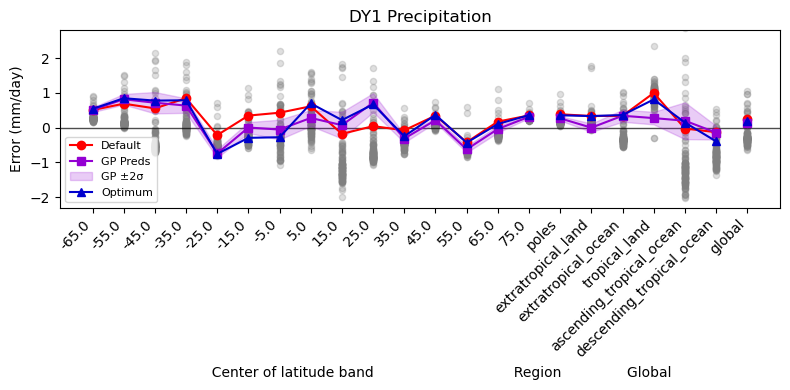

In [51]:
plot_zrg_comparison(
    opt_data     = PM_DY1_opt_mar26_data_small['precip_total_surf_mass_flux']*1e3*24*3600,
    PPE_data     = PCP_train*1e3*24*3600,
    obs_data     = PCP_zrg_obs*1e3*24*3600,
    opt_preds    = PCP_final_preds*1e3*24*3600,
    opt_preds_sd = PCP_final_preds_sd*1e3*24*3600,
    area=area, lat=lat, lon=lon, regions_file=regions_file,
    all_num=22, r_num=6, z_num=15,
    dy="DY1",
    title="Precipitation",
    ylabel="Error (mm/day)",
    ylim=(-2.3,2.8),
    axis_loc = 'lower left'
)


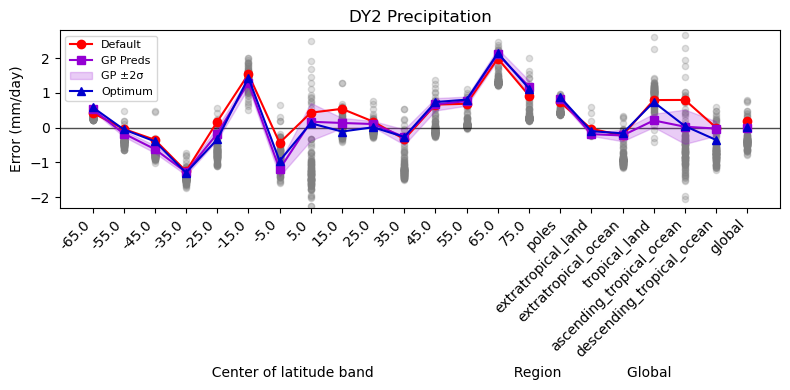

In [52]:
plot_zrg_comparison(
    opt_data     = PM_DY2_opt_mar26_data_small['precip_total_surf_mass_flux']*1e3*24*3600,
    PPE_data     = PCP_train*1e3*24*3600,
    obs_data     = PCP_zrg_obs*1e3*24*3600,
    opt_preds    = PCP_final_preds*1e3*24*3600,
    opt_preds_sd = PCP_final_preds_sd*1e3*24*3600,
    area=area, lat=lat, lon=lon, regions_file=regions_file,
    all_num=22, r_num=6, z_num=15,
    dy="DY2",
    title="Precipitation",
    ylabel="Error (mm/day)",
    ylim=(-2.3,2.8)
)


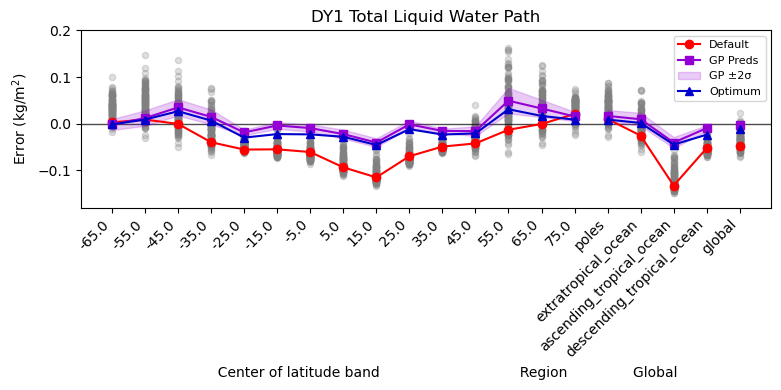

In [45]:
plot_zrg_comparison_TLWP(
    opt_data     = PM_DY1_opt_mar26_data_small['TotalLiqWaterPath'],
    PPE_data     = TLWP_train,
    obs_data     = TLWP_zrg_obs,
    opt_preds    = TLWP_final_preds,
    opt_preds_sd = TLWP_final_preds_sd,
    area=area, lat=lat, lon=lon, regions_file=regions_file,
    all_num=22, r_num=6, z_num=15,
    dy="DY1",
    title="Total Liquid Water Path",
    ylabel="Error (kg/m$^2$)",
    ylim=(-0.18,0.2)
)


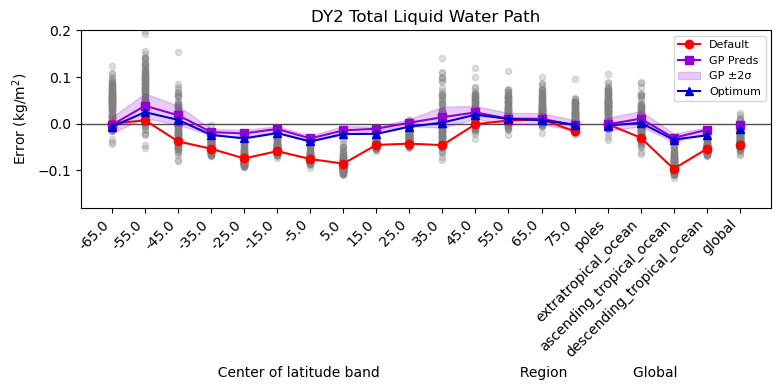

In [46]:
plot_zrg_comparison_TLWP(
    opt_data     = PM_DY2_opt_mar26_data_small['TotalLiqWaterPath'],
    PPE_data     = TLWP_train,
    obs_data     = TLWP_zrg_obs,
    opt_preds    = TLWP_final_preds,
    opt_preds_sd = TLWP_final_preds_sd,
    area=area, lat=lat, lon=lon, regions_file=regions_file,
    all_num=22, r_num=6, z_num=15,
    dy="DY2",
    title="Total Liquid Water Path",
    ylabel="Error (kg/m$^2$)",
    ylim=(-0.18,0.2)
)


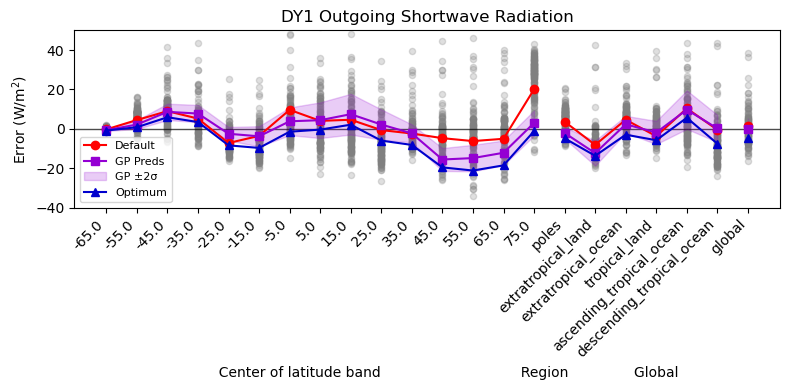

In [79]:
plot_zrg_comparison(
    opt_data     = PM_DY1_opt_mar26_data_small['SW_flux_up_at_model_top'],
    PPE_data     = OSR_train,
    obs_data     = OSR_zrg_obs,
    opt_preds    = OSR_final_preds,
    opt_preds_sd = OSR_final_preds_sd,
    area=area, lat=lat, lon=lon, regions_file=regions_file,
    all_num=22, r_num=6, z_num=15,
    dy="DY1",
    title="Outgoing Shortwave Radiation",
    ylabel="Error (W/m$^2$)",
    ylim=(-40, 50),
)


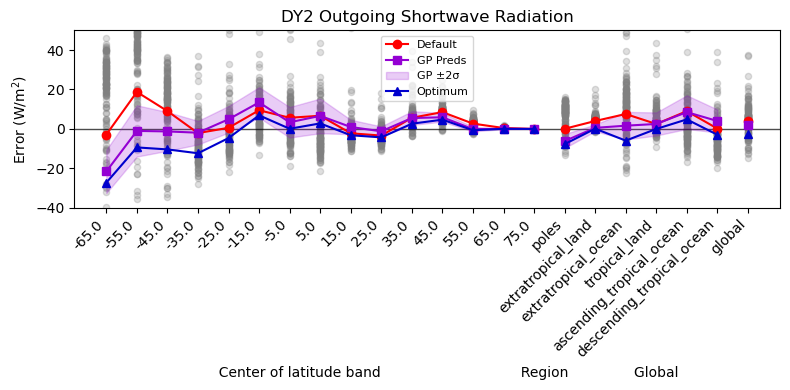

In [80]:
plot_zrg_comparison(
    opt_data     = PM_DY2_opt_mar26_data_small['SW_flux_up_at_model_top'],
    PPE_data     = OSR_train,
    obs_data     = OSR_zrg_obs,
    opt_preds    = OSR_final_preds,
    opt_preds_sd = OSR_final_preds_sd,
    area=area, lat=lat, lon=lon, regions_file=regions_file,
    all_num=22, r_num=6, z_num=15,
    dy="DY2",
    title="Outgoing Shortwave Radiation",
    ylabel="Error (W/m$^2$)",
    ylim=(-40, 50),
)


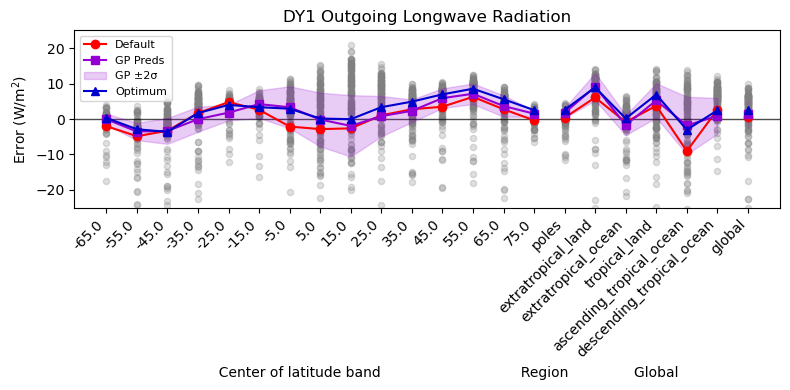

In [81]:
plot_zrg_comparison(
    opt_data     = PM_DY1_opt_mar26_data_small['LW_flux_up_at_model_top'],
    PPE_data     = OLR_train,
    obs_data     = OLR_zrg_obs,
    opt_preds    = OLR_final_preds,
    opt_preds_sd = OLR_final_preds_sd,
    area=area, lat=lat, lon=lon, regions_file=regions_file,
    all_num=22, r_num=6, z_num=15,
    dy="DY1",
    title="Outgoing Longwave Radiation",
    ylabel="Error (W/m$^2$)",
    ylim=(-25, 25),
)


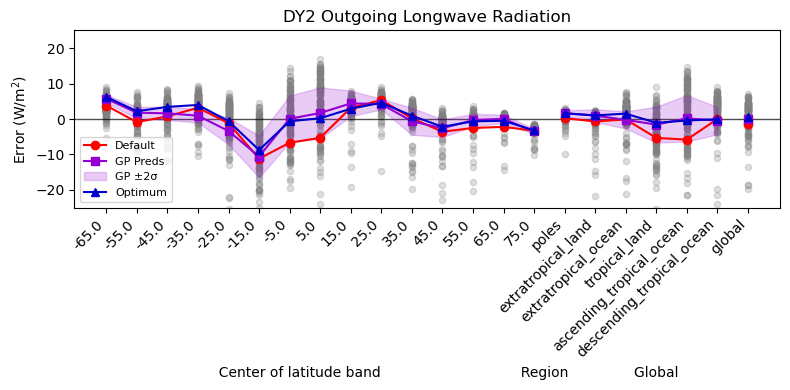

In [82]:
plot_zrg_comparison(
    opt_data     = PM_DY2_opt_mar26_data_small['LW_flux_up_at_model_top'],
    PPE_data     = OLR_train,
    obs_data     = OLR_zrg_obs,
    opt_preds    = OLR_final_preds,
    opt_preds_sd = OLR_final_preds_sd,
    area=area, lat=lat, lon=lon, regions_file=regions_file,
    all_num=22, r_num=6, z_num=15,
    dy="DY2",
    title="Outgoing Longwave Radiation",
    ylabel="Error (W/m$^2$)",
    ylim=(-25, 25),
)


##### Global averages

In [102]:
def plot_multi_variable_global_comparison(
    variables: list[dict],
    title="Global Average vs Error",
    ylabel="Relative Error (bias / obs)",
    ylim=None,
    figsize=(4.5, 4),
):
    default_colours = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    x_positions = []
    ppe_biases  = []
    default_pts = []
    pred_pts    = []
    opt_pts     = []
    labels      = []

    for i, var in enumerate(variables):
        PPE_data  = var["PPE_data"]   # DataFrame: rows=members, single global column
        obs_data  = var["obs_data"]   # scalar, Series, or single-value DataFrame
        opt_preds = var["opt_preds"]  # scalar
        opt_data  = var["opt_data"]
        area      = var["area"]
        label     = var.get("label",  f"Var {i+1}")

        # ── Coerce obs to scalar ──────────────────────────────────────────────
        if hasattr(obs_data, "iloc"):
            obs_global = float(obs_data.iloc[0] if obs_data.ndim == 1 else obs_data.iloc[0, 0])
        else:
            obs_global = float(obs_data)

        if obs_global == 0:
            raise ValueError(f"Variable '{label}': obs global value is 0 — cannot normalise.")

        # ── Coerce PPE_data to a 1-D array of member values ──────────────────
        if PPE_data.ndim == 2:
            ppe_vals = PPE_data.iloc[:, 0].to_numpy(dtype=float)  # single global col
        else:
            ppe_vals = PPE_data.to_numpy(dtype=float)

        global_val = float(global_means_native(opt_data, area))

        ppe_bias_global     = (ppe_vals - obs_global)                        / abs(obs_global)
        default_bias_global = (float(PPE_data.iloc[0]) - obs_global) / abs(obs_global)
        pred_bias_global    = (float(opt_preds)  - obs_global)               / abs(obs_global)
        opt_bias_global     = (global_val        - obs_global)               / abs(obs_global)

        x_positions.append(i)
        ppe_biases.append(ppe_bias_global)
        default_pts.append(default_bias_global)
        pred_pts.append(pred_bias_global)
        opt_pts.append(opt_bias_global)
        labels.append(label)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)
    #fig, ax = plt.subplots()

    for i, (x, ppe) in enumerate(zip(x_positions, ppe_biases)):
        ax.scatter(np.full(len(ppe), x), ppe, color="gray", alpha=0.3, s=20,
                   zorder=3)

    ax.scatter(x_positions, default_pts, marker="o", s=50, color="red",        zorder=4, label="Default")
    ax.scatter(x_positions, pred_pts,    marker="s", s=50, color="darkviolet", zorder=4, label="GP Preds")
    ax.scatter(x_positions, opt_pts,     marker="^", s=50, color="mediumblue", zorder=4, label="Optimum")

    ax.axhline(0, color="black", linewidth=0.9, alpha=0.7, zorder=1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.1f}%"))
    ax.legend(fontsize=8, loc="lower left")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.tight_layout()
    plt.show()

In [85]:
variables_DY1 = [
    {
        "opt_data":  PM_DY1_opt_mar26_data_small['precip_total_surf_mass_flux'],
        "PPE_data":  PCP_train.iloc[:, all_num-1],
        "obs_data":  PCP_zrg_obs.iloc[:, all_num-1],
        "opt_preds": PCP_final_preds[all_num-1],
        "area":      area,
        "label":     "PCP",
    },
    {
        "opt_data":  PM_DY1_opt_mar26_data_small['TotalLiqWaterPath'],
        "PPE_data":  TLWP_train.iloc[:, all_num-1],
        "obs_data":  TLWP_zrg_obs.iloc[:, all_num-1],
        "opt_preds": TLWP_final_preds[all_num-1],
        "area":      area,
        "label":     "TLWP",
    },
    {
        "opt_data":  PM_DY1_opt_mar26_data_small['SW_flux_up_at_model_top'],
        "PPE_data":  OSR_train.iloc[:, all_num-1],
        "obs_data":  OSR_zrg_obs.iloc[:, all_num-1],
        "opt_preds": OSR_final_preds[all_num-1],
        "area":      area,
        "label":     "OSR",
    },
    {
        "opt_data":  PM_DY1_opt_mar26_data_small['LW_flux_up_at_model_top'],
        "PPE_data":  OLR_train.iloc[:, all_num-1],
        "obs_data":  OLR_zrg_obs.iloc[:, all_num-1],
        "opt_preds": OLR_final_preds[all_num-1],
        "area":      area,
        "label":     "OLR",
    }
]

In [86]:
variables_DY2 = [
    {
        "opt_data":  PM_DY2_opt_mar26_data_small['precip_total_surf_mass_flux'],
        "PPE_data":  PCP_train.iloc[:, -1],
        "obs_data":  PCP_zrg_obs.iloc[:, -1],
        "opt_preds": PCP_final_preds[-1],
        "area":      area,
        "label":     "PCP",
    },
    {
        "opt_data":  PM_DY2_opt_mar26_data_small['TotalLiqWaterPath'],
        "PPE_data":  TLWP_train.iloc[:, -1],
        "obs_data":  TLWP_zrg_obs.iloc[:, -1],
        "opt_preds": TLWP_final_preds[-1],
        "area":      area,
        "label":     "TLWP",
    },
    {
        "opt_data":  PM_DY2_opt_mar26_data_small['SW_flux_up_at_model_top'],
        "PPE_data":  OSR_train.iloc[:, -1],
        "obs_data":  OSR_zrg_obs.iloc[:, -1],
        "opt_preds": OSR_final_preds[-1],
        "area":      area,
        "label":     "OSR",
    },
    {
        "opt_data":  PM_DY2_opt_mar26_data_small['LW_flux_up_at_model_top'],
        "PPE_data":  OLR_train.iloc[:, -1],
        "obs_data":  OLR_zrg_obs.iloc[:, -1],
        "opt_preds": OLR_final_preds[-1],
        "area":      area,
        "label":     "OLR",
    }
]

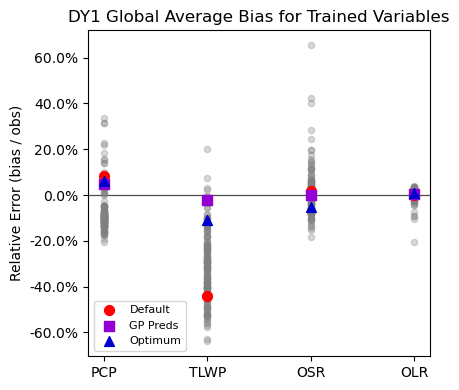

In [103]:
plot_multi_variable_global_comparison(variables = variables_DY1, 
                                      title= "DY1 Global Average Bias for Trained Variables")

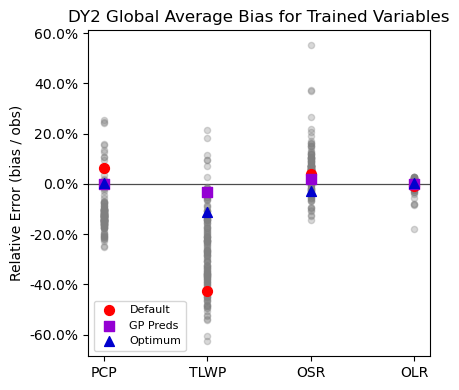

In [104]:
plot_multi_variable_global_comparison(variables = variables_DY2, 
                                      title= "DY2 Global Average Bias for Trained Variables")

### Combined a,b,c figures
Geographic optdef/doublebias maps + the existing rmse-style line plot, composited into one labeled (a.)/(b.)/(c.) figure per variable.

In [32]:
lon_adj = np.where(lon > 180, lon - 360, lon)  # lon is 0-360, convert to -180 to 180


In [33]:
#ppe data set dots
ppe_params = pd.read_pickle(str(paths.ZRG_DIR / 'ppe_param.pkl'))

DY1_path = str(paths.DY1_DIR) + "/" #new scratch location of DY1
DY1_filename_list = []
for label in ppe_params.index:
    file_path = DY1_path+label+'/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2016-08-07-00000.nc'
    DY1_filename_list.append(file_path)

DY2_path = str(paths.DY2_DIR) + "/" #path to the runs
DY2_filename_list = []
for label in ppe_params.index:
    file_path = DY2_path+label+'/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc'
    DY2_filename_list.append(file_path)

In [34]:
DY1_default = xr.open_dataset(DY1_path+'m0000'+'/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2016-08-07-00000.nc').squeeze('time')
DY2_default = xr.open_dataset(DY2_path+'m0000'+'/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc').squeeze('time')

In [72]:
def fig_geographic_optdef(defvar, optvar, title, label, extra_data=None):
    diff = optvar - defvar

    all_diffs = [np.asarray(diff).flatten()]
    if extra_data is not None:
        for def_e, opt_e in extra_data:
            d = np.asarray(opt_e).flatten() - np.asarray(def_e).flatten()
            all_diffs.append(d)
    combined = np.concatenate(all_diffs)
    valid_combined = combined[~np.isnan(combined)]
    absmax = max(abs(np.percentile(valid_combined, 2)), abs(np.percentile(valid_combined, 98)))
    vmin, vmax = -absmax, absmax

    fig, ax = plt.subplots(figsize=(12, 6))
    m = Basemap(projection='robin', lon_0=0, resolution='l', ax=ax)

    mx, my = m(lon_adj, lat)

    triang = tri.Triangulation(mx, my)

    tri_x = mx[triang.triangles]
    tri_y = my[triang.triangles]
    edge_lengths = np.sqrt(
        np.diff(np.c_[tri_x, tri_x[:, 0:1]], axis=1)**2 +
        np.diff(np.c_[tri_y, tri_y[:, 0:1]], axis=1)**2
    )
    x_range = mx.max() - mx.min()
    mask = edge_lengths.max(axis=1) > 0.05 * x_range
    triang.set_mask(mask)

    tcf = plt.tricontourf(triang, diff, cmap='PRGn', vmin=vmin, vmax=vmax, levels=np.linspace(vmin, vmax, 51), extend='both')

    m.drawcoastlines()
    ax.set_title(title + ": Optimum Values - Default Values")
    plt.colorbar(tcf, ax=ax, label=label, shrink=0.8)
    plt.show()


def fig_geographic_doublebias(obsvar, optvar, defvar, title, label, extra_data=None):
    valid = (~np.isnan(obsvar) & ~np.isnan(optvar) & ~np.isnan(defvar)).values

    obsvar_v = obsvar.values[valid]
    optvar_v = optvar.values[valid]
    defvar_v = defvar.values[valid]
    lon_v    = lon_adj[valid]
    lat_v    = lat[valid]

    def_err_var = abs(defvar_v - obsvar_v)
    opt_err_var = abs(optvar_v - obsvar_v)
    diff = opt_err_var - def_err_var

    all_diffs = [diff]
    if extra_data is not None:
        for obs_e, opt_e, def_e in extra_data:
            obs_e = np.asarray(obs_e).flatten()
            opt_e = np.asarray(opt_e).flatten()
            def_e = np.asarray(def_e).flatten()
            d = abs(opt_e - obs_e) - abs(def_e - obs_e)
            all_diffs.append(d[~np.isnan(d)])
    combined = np.concatenate(all_diffs)
    absmax = max(abs(np.percentile(combined, 2)), abs(np.percentile(combined, 98)))

    fig, ax = plt.subplots(figsize=(12, 6))
    m = Basemap(projection='robin', lon_0=0, resolution='l', ax=ax)

    mx, my = m(lon_v, lat_v)

    triang = tri.Triangulation(mx, my)

    finite_mask = ~np.isfinite(diff)
    tri_finite_mask = finite_mask[triang.triangles].any(axis=1)

    tri_x = mx[triang.triangles]
    tri_y = my[triang.triangles]
    edge_lengths = np.sqrt(
        np.diff(np.c_[tri_x, tri_x[:, 0:1]], axis=1)**2 +
        np.diff(np.c_[tri_y, tri_y[:, 0:1]], axis=1)**2
    )
    x_range = mx.max() - mx.min()
    edge_mask = edge_lengths.max(axis=1) > 0.05 * x_range

    triang.set_mask(edge_mask | tri_finite_mask)

    tcf = plt.tricontourf(triang, diff, levels=np.linspace(-absmax, absmax, 21),
                          cmap='bwr', extend='both')

    m.drawcoastlines()
    ax.set_title(title + ": Abs Opt Bias - Abs Default Bias")
    plt.colorbar(tcf, ax=ax, label=label, shrink=0.8)
    plt.show()


def fig_geographic_doublebias_T850(obsvar, optvar, defvar, title, label, extra_data=None):
    defvar = np.asarray(defvar).flatten()
    optvar = np.asarray(optvar).flatten()
    obsvar = np.asarray(obsvar).flatten()
    lon_all = np.asarray(lon_adj).flatten()
    lat_all = np.asarray(lat).flatten()

    valid = ~np.isnan(obsvar) & ~np.isnan(optvar) & ~np.isnan(defvar)
    obsvar_v = obsvar[valid]
    optvar_v = optvar[valid]
    defvar_v = defvar[valid]
    lon_v    = lon_all[valid]
    lat_v    = lat_all[valid]

    def_err_var = abs(defvar_v - obsvar_v)
    opt_err_var = abs(optvar_v - obsvar_v)
    diff = opt_err_var - def_err_var

    all_diffs = [diff]
    if extra_data is not None:
        for obs_e, opt_e, def_e in extra_data:
            obs_e = np.asarray(obs_e).flatten()
            opt_e = np.asarray(opt_e).flatten()
            def_e = np.asarray(def_e).flatten()
            d = abs(opt_e - obs_e) - abs(def_e - obs_e)
            all_diffs.append(d[~np.isnan(d)])
    combined = np.concatenate(all_diffs)
    absmax = max(abs(np.percentile(combined, 2)), abs(np.percentile(combined, 98)))

    fig, ax = plt.subplots(figsize=(12, 6))
    m = Basemap(projection='robin', lon_0=0, resolution='l', ax=ax)
    mx, my = m(lon_v, lat_v)
    triang = tri.Triangulation(mx, my)
    finite_mask = ~np.isfinite(diff)
    tri_finite_mask = finite_mask[triang.triangles].any(axis=1)
    tri_x = mx[triang.triangles]
    tri_y = my[triang.triangles]
    edge_lengths = np.sqrt(
        np.diff(np.c_[tri_x, tri_x[:, 0:1]], axis=1)**2 +
        np.diff(np.c_[tri_y, tri_y[:, 0:1]], axis=1)**2
    )
    x_range = mx.max() - mx.min()
    edge_mask = edge_lengths.max(axis=1) > 0.05 * x_range
    triang.set_mask(edge_mask | tri_finite_mask)
    tcf = plt.tricontourf(triang, diff, levels=np.linspace(-absmax, absmax, 21),
                          cmap='bwr_r', extend='both')
    m.drawcoastlines()
    ax.set_title(title + ": Abs Opt Bias - Abs Default Bias")
    plt.colorbar(tcf, ax=ax, label=label, shrink=0.8)
    plt.show()


In [48]:
def fig_geographic_optdef(defvar, optvar, title, label, extra_data=None):
    diff = np.asarray(optvar - defvar).flatten()

    all_diffs = [diff]
    if extra_data is not None:
        for def_e, opt_e in extra_data:
            d = np.asarray(opt_e).flatten() - np.asarray(def_e).flatten()
            all_diffs.append(d)
    combined = np.concatenate(all_diffs)
    valid_combined = combined[~np.isnan(combined)]
    absmax = max(abs(np.percentile(valid_combined, 2)), abs(np.percentile(valid_combined, 98)))
    vmin, vmax = -absmax, absmax

    fig, ax = plt.subplots(figsize=(12, 6))
    m = Basemap(projection='robin', lon_0=0, resolution='l', ax=ax)

    mx, my = m(lon_adj, lat)

    triang = tri.Triangulation(mx, my)

    # Mask triangles that touch any NaN vertex (e.g. optvar/defvar masked to obs footprint)
    tri_nan_mask = np.isnan(diff)[triang.triangles].any(axis=1)

    tri_x = mx[triang.triangles]
    tri_y = my[triang.triangles]
    edge_lengths = np.sqrt(
        np.diff(np.c_[tri_x, tri_x[:, 0:1]], axis=1)**2 +
        np.diff(np.c_[tri_y, tri_y[:, 0:1]], axis=1)**2
    )
    x_range = mx.max() - mx.min()
    edge_mask = edge_lengths.max(axis=1) > 0.05 * x_range
    triang.set_mask(tri_nan_mask | edge_mask)

    diff_safe = np.where(np.isnan(diff), 0.0, diff)
    tcf = plt.tricontourf(triang, diff_safe, cmap='PRGn', vmin=vmin, vmax=vmax, levels=np.linspace(vmin, vmax, 51), extend='both')

    m.drawcoastlines()
    ax.set_title(title + ": Optimum - Default values")
    plt.colorbar(tcf, ax=ax, label=label, shrink=0.8)
    plt.show()

In [51]:
import io
from PIL import Image

COMBINED_FIGURES_DIR = str(paths.FIGURES_DIR / 'tri_figs')

def render_to_array(plot_func, *args, panel_scale=0.6, **kwargs):
    """Run an existing plotting function headlessly and return its figure as a pixel array.

    panel_scale shrinks the original figure's canvas (in inches) before rasterizing it.
    Font sizes are set in points (absolute), so shrinking the canvas alone makes the
    same text occupy a larger fraction of the panel -- no fontsize needs to change.
    """
    show_orig = plt.show
    plt.show = lambda *a, **k: None
    try:
        plot_func(*args, **kwargs)
        fig = plt.gcf()
        w, h = fig.get_size_inches()
        fig.set_size_inches(w * panel_scale, h * panel_scale)
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
        plt.close(fig)
    finally:
        plt.show = show_orig
    buf.seek(0)
    return np.array(Image.open(buf))


def make_abc_figure(suptitle, panel_calls, figsize=(9, 6.5), panel_scale=0.6, savepath=None):
    """panel_calls: list of 3 (func, args, kwargs) tuples, in a/b/c order.

    panel_scale can be a single float (applied to all three panels) or a list/tuple
    of 3 floats to scale each panel (a, b, c) independently -- handy since the line
    plot (c) often needs a bigger scale than the maps (a, b) to avoid clipped text.
    """
    if isinstance(panel_scale, (list, tuple)):
        scales = panel_scale
    else:
        scales = [panel_scale] * 3
    images = [render_to_array(func, *args, panel_scale=scale, **kwargs)
              for (func, args, kwargs), scale in zip(panel_calls, scales)]

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.85])
    axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, :])]

    with plt.rc_context({'mathtext.fontset': 'cm'}):
        for ax, img, letter in zip(axes, images, ['a', 'b', 'c']):
            ax.imshow(img)
            ax.axis('off')
            ax.text(0.0, 1.0, rf'$\mathrm{{({letter}.)}}$', transform=ax.transAxes,
                    fontsize=14, va='bottom', ha='left')

    #if suptitle:
        #fig.suptitle(suptitle, fontsize=15, y=0.92)
    plt.tight_layout()

    if savepath is None and suptitle:
        os.makedirs(COMBINED_FIGURES_DIR, exist_ok=True)
        savepath = os.path.join(COMBINED_FIGURES_DIR, suptitle.replace(' ', '_') + '.png')
    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()


ValueError: z array must not contain non-finite values within the triangulation

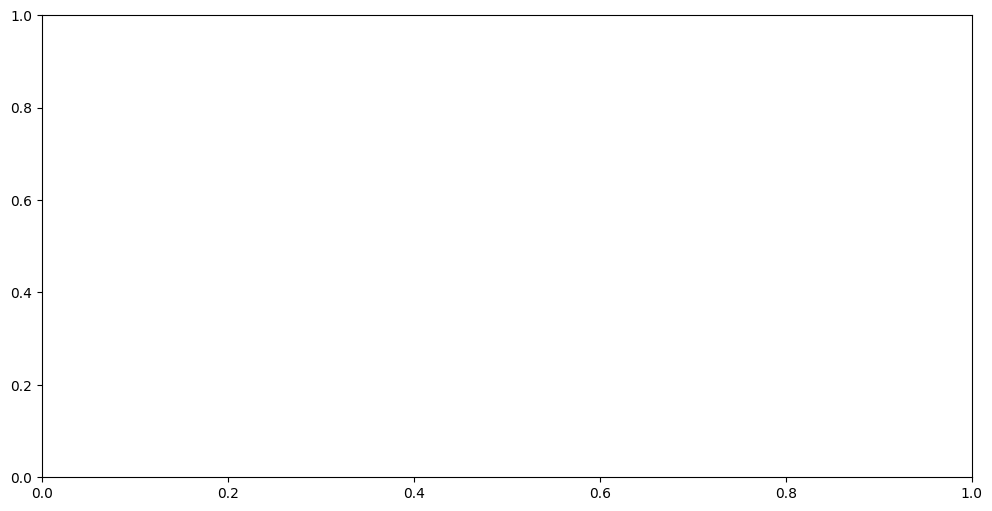

In [73]:
make_abc_figure(
    "DY1 Precipitation",
    [
        (fig_geographic_optdef,
         (DY1_default.precip_total_surf_mass_flux*1e3*24*3600, PM_DY1_opt_mar26_data_small.precip_total_surf_mass_flux*1e3*24*3600, 'DY1 Precipitation', 'PCP (mm/day)'),
         dict(extra_data=[(DY2_default.precip_total_surf_mass_flux*1e3*24*3600, PM_DY2_opt_mar26_data_small.precip_total_surf_mass_flux*1e3*24*3600)])),

        (fig_geographic_doublebias,
         (DY1_PCP_obs*1e3*24*3600, PM_DY1_opt_mar26_data_small.precip_total_surf_mass_flux*1e3*24*3600, DY1_default.precip_total_surf_mass_flux*1e3*24*3600, 'DY1 Precipitation', 'PCP (mm/day)'),
         dict(extra_data=[(DY2_PCP_obs*1e3*24*3600, PM_DY2_opt_mar26_data_small.precip_total_surf_mass_flux*1e3*24*3600, DY2_default.precip_total_surf_mass_flux*1e3*24*3600)])),

        (plot_zrg_comparison, (), dict(
            opt_data=PM_DY1_opt_mar26_data_small['precip_total_surf_mass_flux']*1e3*24*3600,
            PPE_data=PCP_train*1e3*24*3600, obs_data=PCP_zrg_obs*1e3*24*3600,
            opt_preds=PCP_final_preds*1e3*24*3600, opt_preds_sd=PCP_final_preds_sd*1e3*24*3600,
            area=area, lat=lat, lon=lon, regions_file=regions_file,
            all_num=22, r_num=6, z_num=15, dy='DY1', title='Precipitation',
            ylabel='Error (mm/day)', ylim=(-2.3,2.8)
        )),
    ],
    panel_scale=(0.75, 0.68, 0.8),
)


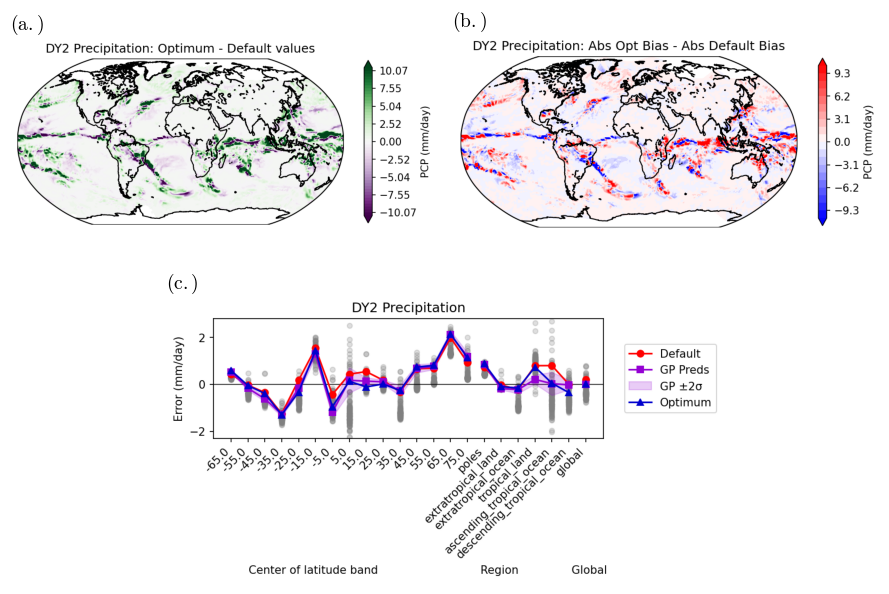

In [64]:
make_abc_figure(
    "DY2 Precipitation",
    [
        (fig_geographic_optdef,
         (DY2_default.precip_total_surf_mass_flux*1e3*24*3600, PM_DY2_opt_mar26_data_small['precip_total_surf_mass_flux']*1e3*24*3600, 'DY2 Precipitation', 'PCP (mm/day)'),
         dict(extra_data=[(DY1_default.precip_total_surf_mass_flux*1e3*24*3600, PM_DY1_opt_mar26_data_small['precip_total_surf_mass_flux']*1e3*24*3600)])),

        (fig_geographic_doublebias,
         (DY2_PCP_obs*1e3*24*3600, PM_DY2_opt_mar26_data_small['precip_total_surf_mass_flux']*1e3*24*3600, DY2_default.precip_total_surf_mass_flux*1e3*24*3600, 'DY2 Precipitation', 'PCP (mm/day)'),
         dict(extra_data=[(DY1_PCP_obs*1e3*24*3600, PM_DY1_opt_mar26_data_small['precip_total_surf_mass_flux']*1e3*24*3600, DY1_default.precip_total_surf_mass_flux*1e3*24*3600)])),

        (plot_zrg_comparison, (), dict(
            opt_data=PM_DY2_opt_mar26_data_small['precip_total_surf_mass_flux']*1e3*24*3600,
            PPE_data=PCP_train*1e3*24*3600, obs_data=PCP_zrg_obs*1e3*24*3600,
            opt_preds=PCP_final_preds*1e3*24*3600, opt_preds_sd=PCP_final_preds_sd*1e3*24*3600,
            area=area, lat=lat, lon=lon, regions_file=regions_file,
            all_num=22, r_num=6, z_num=15, dy='DY2', title='Precipitation',
            ylabel='Error (mm/day)', ylim=(-2.3,2.8)
        )),
    ],
    panel_scale=(0.6, 0.6, 0.85),
)


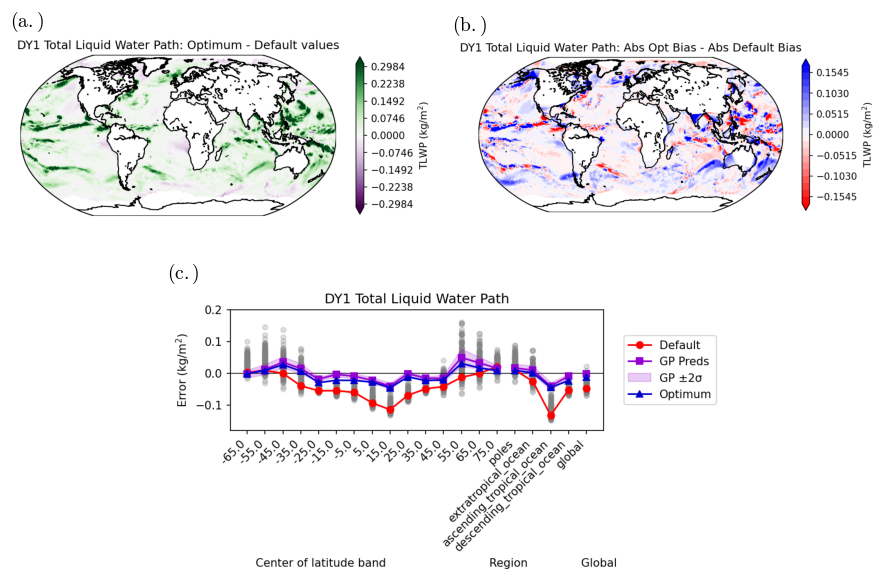

In [65]:
make_abc_figure(
    "DY1 Total Liquid Water Path",
    [
        (fig_geographic_optdef,
         ((DY1_default.LiqWaterPath + DY1_default.RainWaterPath), PM_DY1_opt_mar26_data_small['TotalLiqWaterPath'], 'DY1 Total Liquid Water Path', 'TLWP (kg/m$^2$)'),
         dict(extra_data=[((DY2_default.LiqWaterPath + DY2_default.RainWaterPath), PM_DY2_opt_mar26_data_small['TotalLiqWaterPath'])])),

        (fig_geographic_doublebias_T850,
         (DY1_TLWP_obs, PM_DY1_opt_mar26_data_small['TotalLiqWaterPath'], (DY1_default.LiqWaterPath + DY1_default.RainWaterPath), 'DY1 Total Liquid Water Path', 'TLWP (kg/m$^2$)'),
         dict(extra_data=[(DY2_TLWP_obs, PM_DY2_opt_mar26_data_small['TotalLiqWaterPath'], (DY2_default.LiqWaterPath + DY2_default.RainWaterPath))])),

        (plot_zrg_comparison_TLWP, (), dict(
            opt_data=PM_DY1_opt_mar26_data_small['TotalLiqWaterPath'],
            PPE_data=TLWP_train, obs_data=TLWP_zrg_obs,
            opt_preds=TLWP_final_preds, opt_preds_sd=TLWP_final_preds_sd,
            area=area, lat=lat, lon=lon, regions_file=regions_file,
            all_num=22, r_num=6, z_num=15, dy='DY1', title='Total Liquid Water Path',
            ylabel='Error (kg/m$^2$)', ylim=(-0.18,0.2)
        )),
    ],
    panel_scale=(0.6, 0.6, 0.85),
)


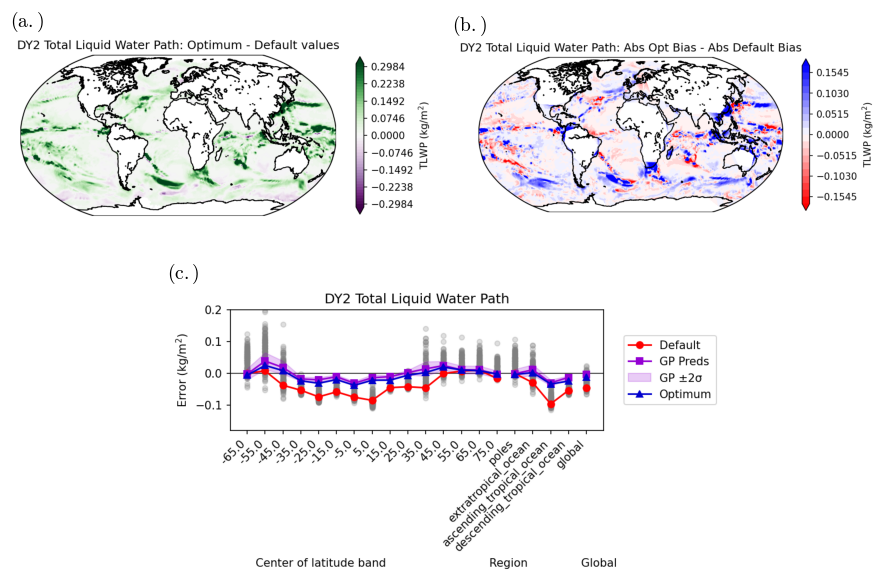

In [66]:
make_abc_figure(
    "DY2 Total Liquid Water Path",
    [
        (fig_geographic_optdef,
         ((DY2_default.LiqWaterPath + DY2_default.RainWaterPath), PM_DY2_opt_mar26_data_small['TotalLiqWaterPath'], 'DY2 Total Liquid Water Path', 'TLWP (kg/m$^2$)'),
         dict(extra_data=[((DY1_default.LiqWaterPath + DY1_default.RainWaterPath), PM_DY1_opt_mar26_data_small['TotalLiqWaterPath'])])),

        (fig_geographic_doublebias_T850,
         (DY2_TLWP_obs, PM_DY2_opt_mar26_data_small['TotalLiqWaterPath'], (DY2_default.LiqWaterPath + DY2_default.RainWaterPath), 'DY2 Total Liquid Water Path', 'TLWP (kg/m$^2$)'),
         dict(extra_data=[(DY1_TLWP_obs, PM_DY1_opt_mar26_data_small['TotalLiqWaterPath'], (DY1_default.LiqWaterPath + DY1_default.RainWaterPath))])),

        (plot_zrg_comparison_TLWP, (), dict(
            opt_data=PM_DY2_opt_mar26_data_small['TotalLiqWaterPath'],
            PPE_data=TLWP_train, obs_data=TLWP_zrg_obs,
            opt_preds=TLWP_final_preds, opt_preds_sd=TLWP_final_preds_sd,
            area=area, lat=lat, lon=lon, regions_file=regions_file,
            all_num=22, r_num=6, z_num=15, dy='DY2', title='Total Liquid Water Path',
            ylabel='Error (kg/m$^2$)', ylim=(-0.18,0.2)
        )),
    ],
    panel_scale=(0.6, 0.6, 0.85),
)


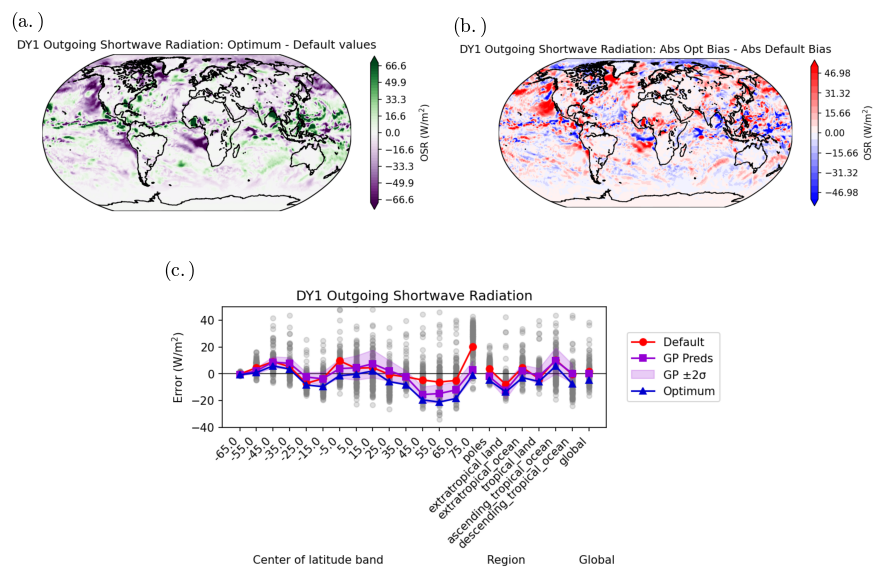

In [67]:
make_abc_figure(
    "DY1 Outgoing Shortwave Radiation",
    [
        (fig_geographic_optdef,
         (DY1_default.SW_flux_up_at_model_top, PM_DY1_opt_mar26_data_small['SW_flux_up_at_model_top'], 'DY1 Outgoing Shortwave Radiation', 'OSR (W/m$^2$)'),
         dict(extra_data=[(DY2_default.SW_flux_up_at_model_top, PM_DY2_opt_mar26_data_small['SW_flux_up_at_model_top'])])),

        (fig_geographic_doublebias,
         (DY1_OSR_obs, PM_DY1_opt_mar26_data_small['SW_flux_up_at_model_top'], DY1_default.SW_flux_up_at_model_top, 'DY1 Outgoing Shortwave Radiation', 'OSR (W/m$^2$)'),
         dict(extra_data=[(DY2_OSR_obs, PM_DY2_opt_mar26_data_small['SW_flux_up_at_model_top'], DY2_default.SW_flux_up_at_model_top)])),

        (plot_zrg_comparison, (), dict(
            opt_data=PM_DY1_opt_mar26_data_small['SW_flux_up_at_model_top'],
            PPE_data=OSR_train, obs_data=OSR_zrg_obs,
            opt_preds=OSR_final_preds, opt_preds_sd=OSR_final_preds_sd,
            area=area, lat=lat, lon=lon, regions_file=regions_file,
            all_num=22, r_num=6, z_num=15, dy='DY1', title='Outgoing Shortwave Radiation',
            ylabel='Error (W/m$^2$)', ylim=(-40, 50)
        )),
    ],
    panel_scale=(0.6, 0.6, 0.85),
)


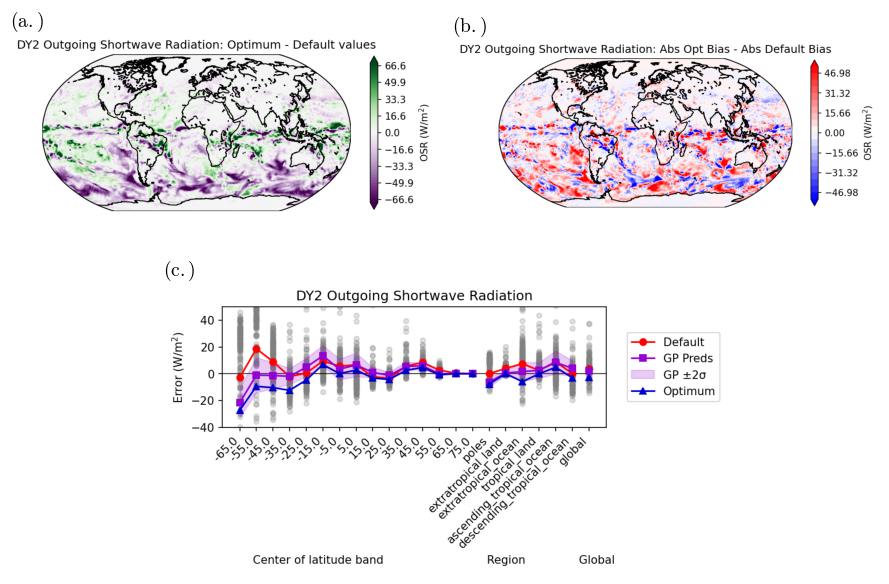

In [69]:
make_abc_figure(
    "DY2 Outgoing Shortwave Radiation",
    [
        (fig_geographic_optdef,
         (DY2_default.SW_flux_up_at_model_top, PM_DY2_opt_mar26_data_small['SW_flux_up_at_model_top'], 'DY2 Outgoing Shortwave Radiation', 'OSR (W/m$^2$)'),
         dict(extra_data=[(DY1_default.SW_flux_up_at_model_top, PM_DY1_opt_mar26_data_small['SW_flux_up_at_model_top'])])),

        (fig_geographic_doublebias,
         (DY2_OSR_obs, PM_DY2_opt_mar26_data_small['SW_flux_up_at_model_top'], DY2_default.SW_flux_up_at_model_top, 'DY2 Outgoing Shortwave Radiation', 'OSR (W/m$^2$)'),
         dict(extra_data=[(DY1_OSR_obs, PM_DY1_opt_mar26_data_small['SW_flux_up_at_model_top'], DY1_default.SW_flux_up_at_model_top)])),

        (plot_zrg_comparison, (), dict(
            opt_data=PM_DY2_opt_mar26_data_small['SW_flux_up_at_model_top'],
            PPE_data=OSR_train, obs_data=OSR_zrg_obs,
            opt_preds=OSR_final_preds, opt_preds_sd=OSR_final_preds_sd,
            area=area, lat=lat, lon=lon, regions_file=regions_file,
            all_num=22, r_num=6, z_num=15, dy='DY2', title='Outgoing Shortwave Radiation',
            ylabel='Error (W/m$^2$)', ylim=(-40, 50)
        )),
    ],
    panel_scale=(0.6, 0.6, 0.85),
)


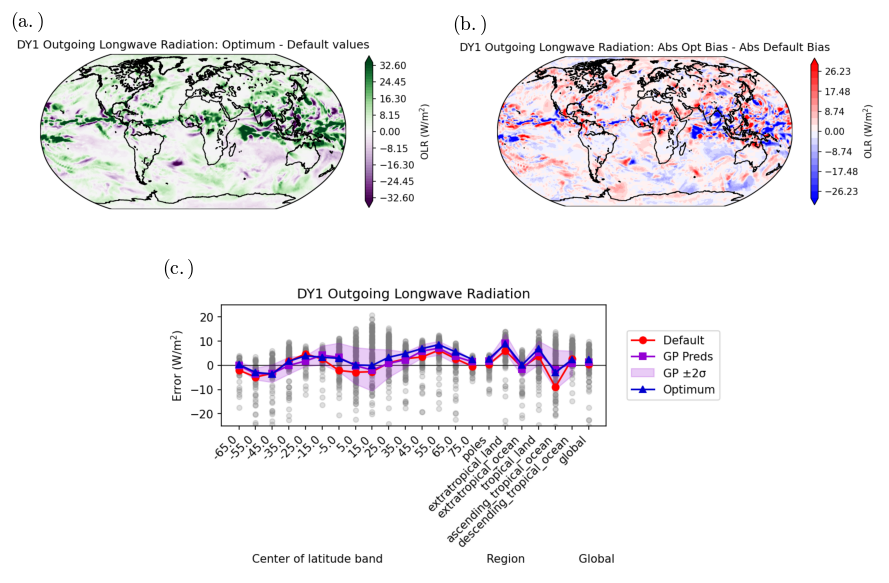

In [70]:
make_abc_figure(
    "DY1 Outgoing Longwave Radiation",
    [
        (fig_geographic_optdef,
         (DY1_default.LW_flux_up_at_model_top, PM_DY1_opt_mar26_data_small['LW_flux_up_at_model_top'], 'DY1 Outgoing Longwave Radiation', 'OLR (W/m$^2$)'),
         dict(extra_data=[(DY2_default.LW_flux_up_at_model_top, PM_DY2_opt_mar26_data_small['LW_flux_up_at_model_top'])])),

        (fig_geographic_doublebias,
         (DY1_OLR_obs, PM_DY1_opt_mar26_data_small['LW_flux_up_at_model_top'], DY1_default.LW_flux_up_at_model_top, 'DY1 Outgoing Longwave Radiation', 'OLR (W/m$^2$)'),
         dict(extra_data=[(DY2_OLR_obs, PM_DY2_opt_mar26_data_small['LW_flux_up_at_model_top'], DY2_default.LW_flux_up_at_model_top)])),

        (plot_zrg_comparison, (), dict(
            opt_data=PM_DY1_opt_mar26_data_small['LW_flux_up_at_model_top'],
            PPE_data=OLR_train, obs_data=OLR_zrg_obs,
            opt_preds=OLR_final_preds, opt_preds_sd=OLR_final_preds_sd,
            area=area, lat=lat, lon=lon, regions_file=regions_file,
            all_num=22, r_num=6, z_num=15, dy='DY1', title='Outgoing Longwave Radiation',
            ylabel='Error (W/m$^2$)', ylim=(-25, 25)
        )),
    ],
    panel_scale=(0.6, 0.6, 0.85),
)


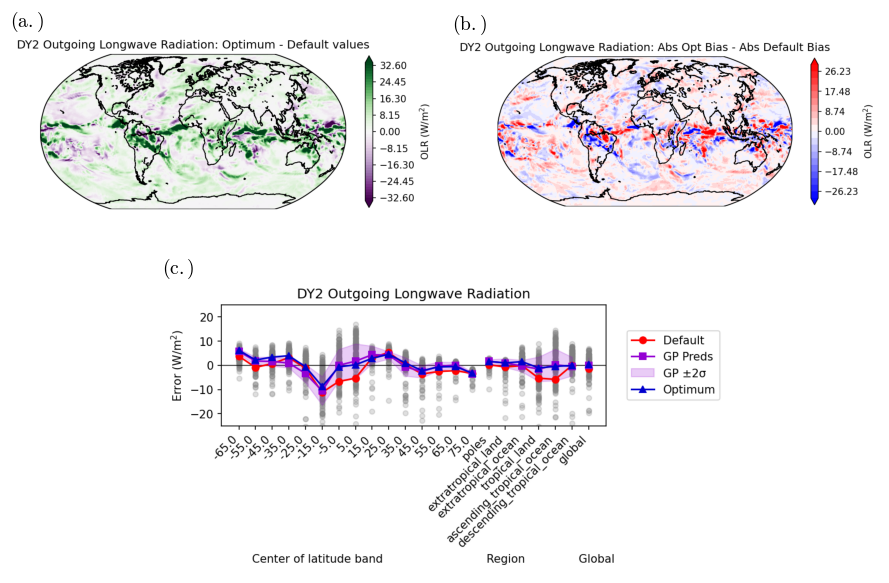

In [71]:
make_abc_figure(
    "DY2 Outgoing Longwave Radiation",
    [
        (fig_geographic_optdef,
         (DY2_default.LW_flux_up_at_model_top, PM_DY2_opt_mar26_data_small['LW_flux_up_at_model_top'], 'DY2 Outgoing Longwave Radiation', 'OLR (W/m$^2$)'),
         dict(extra_data=[(DY1_default.LW_flux_up_at_model_top, PM_DY1_opt_mar26_data_small['LW_flux_up_at_model_top'])])),

        (fig_geographic_doublebias,
         (DY2_OLR_obs, PM_DY2_opt_mar26_data_small['LW_flux_up_at_model_top'], DY2_default.LW_flux_up_at_model_top, 'DY2 Outgoing Longwave Radiation', 'OLR (W/m$^2$)'),
         dict(extra_data=[(DY1_OLR_obs, PM_DY1_opt_mar26_data_small['LW_flux_up_at_model_top'], DY1_default.LW_flux_up_at_model_top)])),

        (plot_zrg_comparison, (), dict(
            opt_data=PM_DY2_opt_mar26_data_small['LW_flux_up_at_model_top'],
            PPE_data=OLR_train, obs_data=OLR_zrg_obs,
            opt_preds=OLR_final_preds, opt_preds_sd=OLR_final_preds_sd,
            area=area, lat=lat, lon=lon, regions_file=regions_file,
            all_num=22, r_num=6, z_num=15, dy='DY2', title='Outgoing Longwave Radiation',
            ylabel='Error (W/m$^2$)', ylim=(-25, 25)
        )),
    ],
    panel_scale=(0.6, 0.6, 0.85),
)
